# PySR pour les modeles de dose

Ce notebook compare les modeles analytiques de l'application Streamlit avec une regression symbolique PySR, sur un ensemble physique defini par une particule, un ecran, un cas, un code et toutes les epaisseurs disponibles.

Flux de travail : regler les parametres utilisateur, charger les donnees, fitter les modeles analytiques, fitter PySR, comparer au meilleur modele existant, puis visualiser les deux courbes.

## Mode d'emploi rapide

Les cellules importantes sont :

- **Parametres utilisateur** : choix de l'ensemble physique, split, budget PySR et benchmark optionnel.
- **Ajustement des references analytiques** : meilleur modele deja implemente.
- **Entrainement PySR** : recherche symbolique et selection du meilleur candidat classe sur le test.
- **Visualisation** : comparaison directe entre PySR et le meilleur modele existant.

## Installation PySR

PySR installe ses dependances Julia au premier import. La cellule suivante ne lance rien tant que `INSTALL_PYSR` reste a `False`. Passez-le a `True` si le package n'est pas encore disponible dans l'environnement du notebook.

In [1]:
INSTALL_PYSR = False
FORCE_REINSTALL_PYSR = False

import sys
import subprocess
from importlib import util
from importlib.metadata import PackageNotFoundError, version

module_to_package = {
    "pysr": "pysr",
    "sklearn": "scikit-learn",
}

packages_to_install = [
    package_name
    for module_name, package_name in module_to_package.items()
    if FORCE_REINSTALL_PYSR or util.find_spec(module_name) is None
]

if packages_to_install:
    if not INSTALL_PYSR:
        raise ImportError(
            "Packages manquants pour PySR: "
            f"{packages_to_install}. Passez INSTALL_PYSR a True pour les installer."
        )

    print(f"Installation demandee pour: {packages_to_install}")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *packages_to_install,
    ])
    print("Installation terminee. Si l'import PySR echoue encore, redemarrez le kernel une fois.")
else:
    def _safe_version(package_name):
        try:
            return version(package_name)
        except PackageNotFoundError:
            return "version inconnue"

    print("PySR deja disponible, aucune reinstallation lancee.")
    print(f"pysr=={_safe_version('pysr')}")
    print(f"scikit-learn=={_safe_version('scikit-learn')}")

PySR deja disponible, aucune reinstallation lancee.
pysr==1.5.10
scikit-learn==1.2.2


## Imports et chemins

Le notebook peut etre lance depuis le dossier racine du projet ou depuis `Notebooks/`.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=RuntimeWarning)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd
DB_PATH = PROJECT_ROOT / "Database" / "All-at-once_DB.xlsx"

def filter_wall_df(data, particles, screens, cases, codes, thicknesses, plot=False):
    filtered = data[
        data["Particle"].isin(particles)
        & data["Screen"].isin(screens)
        & data["Case"].isin(cases)
        & data["Code"].isin(codes)
    ].copy()

    if thicknesses:
        filtered = filtered[filtered["Thickness (cm)"].isin(thicknesses)].copy()

    if "Absolute Uncertainty" not in filtered.columns:
        filtered["Absolute Uncertainty"] = filtered["1s uncertainty"] * filtered["Dose"]

    filtered["Filter Combo"] = filtered.apply(
        lambda row: f"{row['Particle']}_{row['Screen']}_{row['Code']}_{row['Case']}_{row['Thickness (cm)']}",
        axis=1,
    )

    if plot:
        for combo, group in filtered.groupby("Filter Combo"):
            plt.loglog(group["Distance (m)"], group["Dose"], "o-", label=combo)
        plt.xlabel("Distance (m)")
        plt.ylabel("Dose (Gy)")
        plt.grid(True, which="both", linestyle="--", alpha=0.3)
        plt.legend()
        plt.show()

    return filtered

print(f"Project root: {PROJECT_ROOT}")
print(f"Database: {DB_PATH}")
print(f"Database exists: {DB_PATH.exists()}")

Project root: C:\Users\herth-joh01\Documents\GitHub_repo\SR_app
Database: C:\Users\herth-joh01\Documents\GitHub_repo\SR_app\Database\All-at-once_DB.xlsx
Database exists: True


## Chargement des donnees

Le tableau ci-dessous liste les configurations les plus fournies. Il aide a choisir un cas ou PySR aura assez de points pour chercher une equation stable.

In [3]:
data = pd.read_excel(DB_PATH, sheet_name="wall")

required_columns = [
    "Fissile",
    "Case",
    "Code",
    "Screen",
    "Thickness (cm)",
    "Particle",
    "Distance (m)",
    "Dose",
    "1s uncertainty",
]
missing_columns = [col for col in required_columns if col not in data.columns]
if missing_columns:
    raise ValueError(f"Colonnes manquantes dans la base: {missing_columns}")

data = data.copy()
data["Absolute Uncertainty"] = data["Dose"] * data["1s uncertainty"]

config_summary = (
    data.dropna(subset=["Dose", "Distance (m)", "Thickness (cm)"])
    .query("`Dose` > 0 and `Distance (m)` > 0")
    .groupby(["Particle", "Screen", "Case", "Code"], dropna=False)
    .agg(
        points=("Dose", "size"),
        n_thickness=("Thickness (cm)", "nunique"),
        n_distance=("Distance (m)", "nunique"),
        dose_min=("Dose", "min"),
        dose_max=("Dose", "max"),
    )
    .sort_values(["points", "n_thickness", "n_distance"], ascending=False)
)

display(config_summary.head(25))
print(f"Total lignes wall: {len(data)}")

points  n_thickness  \
Particle Screen   Case                    Code                            
N        Concrete C1 [239Pu (H/Pu = 0)]   MCNP 6        65            5   
                  C4 [239Pu (H/Pu = 900)] MCNP 6        65            5   
         Lead     C1 [239Pu (H/Pu = 0)]   MCNP 6        65            5   
                  C4 [239Pu (H/Pu = 900)] MCNP 6        65            5   
         Steel    C1 [239Pu (H/Pu = 0)]   MCNP 6        65            5   
                  C4 [239Pu (H/Pu = 900)] MCNP 6        65            5   
         Water    C1 [239Pu (H/Pu = 0)]   MCNP 6        65            5   
                  C4 [239Pu (H/Pu = 900)] MCNP 6        65            5   
P        Concrete C1 [239Pu (H/Pu = 0)]   MCNP 6        65            5   
                  C4 [239Pu (H/Pu = 900)] MCNP 6        65            5   
         Lead     C1 [239Pu (H/Pu = 0)]   MCNP 6        65            5   
                  C4 [239Pu (H/Pu = 900)] MCNP 6        65            5   
         Steel    C1 [239Pu (H/Pu = 0)]   MCNP 6        65            5   
                  C4 [239Pu (H/Pu = 900)] MCNP 6        65            5   
         Water    C1 [239Pu (H/Pu = 0)]   MCNP 6        65            5   
                  C4 [239Pu (H/Pu = 900)] MCNP 6        65            5   
N        Steel    C1 [239Pu (H/Pu = 0)]   COG 11.2      63            5   
         Lead     C1 [239Pu (H/Pu = 0)]   COG 11.2      62            5   
         Steel    C4 [239Pu (H/Pu = 900)] COG 11.2      59            5   
P        Lead     C1 [239Pu (H/Pu = 0)]   COG 11.2      59            5   
         Steel    C1 [239Pu (H/Pu = 0)]   COG 11.2      58            5   
N        Lead     C4 [239Pu (H/Pu = 900)] COG 11.2      58            5   
         Concrete C4 [239Pu (H/Pu = 900)] COG 11.2      57            5   
P        Water    C1 [239Pu (H/Pu = 0)]   COG 11.2      57            5   
N        Concrete C1 [239Pu (H/Pu = 0)]   COG 11.2      57            5   

                                                    n_distance      dose_min  \
Particle Screen   Case                    Code                                 
N        Concrete C1 [239Pu (H/Pu = 0)]   MCNP 6            13  5.871388e-09   
                  C4 [239Pu (H/Pu = 900)] MCNP 6            13  2.443782e-09   
         Lead     C1 [239Pu (H/Pu = 0)]   MCNP 6            13  3.743126e-08   
                  C4 [239Pu (H/Pu = 900)] MCNP 6            13  1.392851e-08   
         Steel    C1 [239Pu (H/Pu = 0)]   MCNP 6            13  8.033376e-09   
                  C4 [239Pu (H/Pu = 900)] MCNP 6            13  2.796722e-09   
         Water    C1 [239Pu (H/Pu = 0)]   MCNP 6            13  8.779297e-10   
                  C4 [239Pu (H/Pu = 900)] MCNP 6            13  4.013270e-10   
P        Concrete C1 [239Pu (H/Pu = 0)]   MCNP 6            13  2.390000e-08   
                  C4 [239Pu (H/Pu = 900)] MCNP 6            13  2.050000e-08   
         Lead     C1 [239Pu (H/Pu = 0)]   MCNP 6            13  1.320000e-08   
                  C4 [239Pu (H/Pu = 900)] MCNP 6            13  4.440000e-09   
         Steel    C1 [239Pu (H/Pu = 0)]   MCNP 6            13  8.610000e-09   
                  C4 [239Pu (H/Pu = 900)] MCNP 6            13  2.860000e-09   
         Water    C1 [239Pu (H/Pu = 0)]   MCNP 6            13  3.590000e-08   
                  C4 [239Pu (H/Pu = 900)] MCNP 6            13  4.580000e-08   
N        Steel    C1 [239Pu (H/Pu = 0)]   COG 11.2          13  3.352700e-08   
         Lead     C1 [239Pu (H/Pu = 0)]   COG 11.2          13  7.058300e-09   
         Steel    C4 [239Pu (H/Pu = 900)] COG 11.2          13  5.282100e-08   
P        Lead     C1 [239Pu (H/Pu = 0)]   COG 11.2          13  9.614100e-09   
         Steel    C1 [239Pu (H/Pu = 0)]   COG 11.2          13  1.013100e-08   
N        Lead     C4 [239Pu (H/Pu = 900)] COG 11.2          12  1.873500e-08   
         Concrete C4 [239Pu (H/Pu = 900)] COG 11.2          13  3.707700e-13   
P        Water    C1 [239P

Total lignes wall: 4524


## Parametres utilisateur

Modifiez principalement cette cellule pour affiner les resultats PySR. Le notebook cherche un modele pour **un seul ensemble physique a la fois** : une particule, un ecran, un cas, un code, et toutes les epaisseurs sauf si `thicknesses` est renseigne.

In [4]:
# ── Ensemble physique ─────────────────────────────────────────────────────
particles = ["P"]
screens = ["Lead"] #Steel, Lead, Concrete, Water
cases = ["C1 [239Pu (H/Pu = 0)]"]
codes = ["MCNP 6"]
thicknesses = []  # [] = toutes les epaisseurs disponibles
INCLUDE_T0_NONE = True   # Ajoute T=0 (Screen=None) comme reference non-blindee

# ── Split train / test ────────────────────────────────────────────────────
# "holdout_thickness" : une epaisseur entiere reservee pour le test.
# "random"            : melange aleatoire (fraction TEST_FRACTION).
SPLIT_MODE = "holdout_thickness"
HOLDOUT_THICKNESSES = [10]  # epaisseur intermediaire reservee pour le test
TEST_FRACTION = 0.20
RANDOM_SEED = 123

# ── Budget PySR ───────────────────────────────────────────────────────────
# "quick" ~2 min | "medium" ~4 min | "extended" ~6 min
# "deep"  ~12 min | "ultra"  ~25 min  <- recommande pour battre Skyshine Enhanced
PYSR_ACTIVE_STAGES = ["extended", "deep", "ultra"]

# "all"   : selection par erreur max sur toutes les epaisseurs (recommande).
# "test"  : selection sur le test holdout uniquement.
# "train" : selection sur le train.
PYSR_SELECTION_SPLIT = "all"
PYSR_TOP_EQUATIONS_PER_STAGE = 20
PYSR_VERBOSE = False

# ── Operateurs ────────────────────────────────────────────────────────────
PYSR_BINARY_OPERATORS = ["+", "-", "*", "/"]
# exp    : attenuation exponentielle (indispensable)
# square : termes quadratiques du build-up
# sqrt   : build-up en racine carree
# log    : structures logarithmiques
PYSR_UNARY_OPERATORS = ["exp", "square", "sqrt", "log"]

# parsimony bas (0.0001) : autorise des equations complexes.
# weight_optimize eleve (0.01) : meilleure precision des constantes.
PYSR_EXTRA_KWARGS = {"parsimony": 0.0001, "weight_optimize": 0.01}

# ── Features physiques ────────────────────────────────────────────────────
# USE_PHYSICS_FEATURES      : exp_r_decay, inv_r2, T2_scaled
# USE_EXTENDED_PHYSICS_FEATURES : log_r_x_T, log_1pT, r_x_T,
#   + exp_T_decay = exp(-T_scaled) : attenuation par l'epaisseur (crucial)
#   + inv_r2_x_eT = inv_r2 * exp_T_decay : terme direct D ~ 1/r2 * exp(-muT)
USE_PHYSICS_FEATURES = True
USE_EXTENDED_PHYSICS_FEATURES = True

# ── Mode residuel (avance) ────────────────────────────────────────────────
# PySR cherche la correction log-espace au meilleur modele analytique :
# prediction finale : D = D_baseline * exp(correction_PySR)
USE_RESIDUAL_MODE = False
RESIDUAL_BASELINE_MODEL = 'auto'

# ── Selection par couverture des epaisseurs ───────────────────────────────
PYSR_RANK_BY_WORST_THICKNESS = True  # minimise l'erreur de la pire epaisseur
PYSR_WEIGHT_BY_THICKNESS = True      # poids egaux par epaisseur dans la perte

# ── Benchmark multi-ensembles (optionnel, couteux) ───────────────────────
RUN_SCENARIO_BENCHMARK = False
SCENARIO_AUTO_MAX = 5
SCENARIO_STAGE_LABELS = ["quick", "medium"]
SCENARIO_MANUAL_OVERRIDES = [
    {"name": "P_Lead_C1",     "particles": ["P"], "screens": ["Lead"],     "cases": ["C1 [239Pu (H/Pu = 0)]"],    "codes": ["MCNP 6.3"], "thicknesses": []},
    {"name": "P_Lead_C5",     "particles": ["P"], "screens": ["Lead"],     "cases": ["C5 [239Pu (H/Pu = 2000)]"], "codes": ["MCNP 6.3"], "thicknesses": []},
    {"name": "P_Concrete_C3", "particles": ["P"], "screens": ["Concrete"], "cases": ["C3 [239Pu (H/Pu = 100)]"],  "codes": ["MCNP 6.3"], "thicknesses": []},
    {"name": "N_Concrete_C3", "particles": ["N"], "screens": ["Concrete"], "cases": ["C3 [239Pu (H/Pu = 100)]"],  "codes": ["MCNP 6.3"], "thicknesses": []},
    {"name": "N_Lead_C3",     "particles": ["N"], "screens": ["Lead"],     "cases": ["C3 [239Pu (H/Pu = 100)]"],  "codes": ["MCNP 6.3"], "thicknesses": []},
]

print("Ensemble courant:", {"particles": particles, "screens": screens,
      "cases": cases, "codes": codes, "thicknesses": thicknesses or "toutes"})
print("PySR:", {"stages": PYSR_ACTIVE_STAGES, "selection": PYSR_SELECTION_SPLIT,
      "top_per_stage": PYSR_TOP_EQUATIONS_PER_STAGE, "operators": PYSR_UNARY_OPERATORS,
      "parsimony": PYSR_EXTRA_KWARGS.get("parsimony"), "rank_worst_T": PYSR_RANK_BY_WORST_THICKNESS})

Ensemble courant: {'particles': ['P'], 'screens': ['Lead'], 'cases': ['C1 [239Pu (H/Pu = 0)]'], 'codes': ['MCNP 6'], 'thicknesses': 'toutes'}
PySR: {'stages': ['extended', 'deep', 'ultra'], 'selection': 'all', 'top_per_stage': 20, 'operators': ['exp', 'square', 'sqrt', 'log'], 'parsimony': 0.0001, 'rank_worst_T': True}


## Preparation des donnees

La cible PySR est `log_D = ln(Dose)`. Les variables d'entree sont `log_r`, `r_scaled` et `T_scaled`, afin de garder des constantes numeriquement raisonnables.

In [5]:
def clean_fit_data(frame):
    clean = frame.copy()
    clean = clean.dropna(subset=["Dose", "Distance (m)", "Thickness (cm)"])
    clean = clean[(clean["Dose"] > 0) & (clean["Distance (m)"] > 0)]
    return clean.sort_values(["Thickness (cm)", "Distance (m)"]).reset_index(drop=True)

for label, values in {"particles": particles, "screens": screens, "cases": cases, "codes": codes}.items():
    if len(values) != 1:
        raise ValueError(f"Le notebook fit un seul ensemble a la fois: {label} doit contenir exactement 1 valeur.")

filtered_data = filter_wall_df(data, particles, screens, cases, codes, thicknesses, plot=False)
filtered_data = clean_fit_data(filtered_data)

if INCLUDE_T0_NONE:
    t0_data = data[
        data["Particle"].isin(particles)
        & (data["Screen"] == "None")
        & data["Case"].isin(cases)
        & data["Code"].isin(codes)
        & (data["Thickness (cm)"] == 0)
    ].copy()
    t0_data = clean_fit_data(t0_data)
    if not t0_data.empty:
        filtered_data = pd.concat([filtered_data, t0_data], ignore_index=True)
        filtered_data = filtered_data.sort_values(["Thickness (cm)", "Distance (m)"]).reset_index(drop=True)
        print(f"  + {len(t0_data)} points T=0 (Screen=None) ajoutes")

if filtered_data.empty:
    raise ValueError("Aucune donnee valide apres filtrage. Verifiez les parametres utilisateur.")

available_thicknesses = sorted(filtered_data["Thickness (cm)"].unique())
rng = np.random.default_rng(RANDOM_SEED)

if SPLIT_MODE == "holdout_thickness" and set(HOLDOUT_THICKNESSES).issubset(set(available_thicknesses)):
    test_mask = filtered_data["Thickness (cm)"].isin(HOLDOUT_THICKNESSES)
    split_used = "holdout_thickness"
else:
    shuffled_idx = rng.permutation(filtered_data.index.to_numpy())
    n_test = max(1, int(round(TEST_FRACTION * len(shuffled_idx))))
    test_idx = set(shuffled_idx[:n_test])
    test_mask = filtered_data.index.isin(test_idx)
    split_used = "random"

train_df = filtered_data.loc[~test_mask].reset_index(drop=True)
test_df = filtered_data.loc[test_mask].reset_index(drop=True)
if train_df.empty or test_df.empty:
    raise ValueError("Split invalide: train ou test vide. Changez SPLIT_MODE ou HOLDOUT_THICKNESSES.")

R_SCALE = float(train_df["Distance (m)"].max())
T_SCALE = float(max(train_df["Thickness (cm)"].max(), 1.0))

def make_feature_frame(frame):
    r = frame["Distance (m)"].to_numpy(dtype=float)
    T = frame["Thickness (cm)"].to_numpy(dtype=float)
    r_s = r / R_SCALE
    T_s = T / T_SCALE
    features = {
        "log_r": np.log(r),
        "r_scaled": r_s,
        "T_scaled": T_s,
    }
    if USE_PHYSICS_FEATURES:
        features["exp_r_decay"] = np.exp(-r_s)
        features["inv_r2"] = 1.0 / np.maximum(r_s ** 2, 1e-12)
        features["T2_scaled"] = T_s ** 2
    return pd.DataFrame(features)

X_train = make_feature_frame(train_df)
y_train_log = np.log(train_df["Dose"].to_numpy(dtype=float))
X_test = make_feature_frame(test_df)
y_test_log = np.log(test_df["Dose"].to_numpy(dtype=float))

dataset_summary = pd.DataFrame([{
    "points": len(filtered_data),
    "train_points": len(train_df),
    "test_points": len(test_df),
    "split_used": split_used,
    "thicknesses_all": available_thicknesses,
    "thicknesses_train": sorted(train_df["Thickness (cm)"].unique()),
    "thicknesses_test": sorted(test_df["Thickness (cm)"].unique()),
    "R_SCALE": R_SCALE,
    "T_SCALE": T_SCALE,
    "features": list(X_train.columns),
}])
display(dataset_summary)

  + 13 points T=0 (Screen=None) ajoutes


,points,train_points,test_points,split_used,thicknesses_all,thicknesses_train,thicknesses_test,R_SCALE,T_SCALE,features
0,78,65,13,holdout_thickness,"[0, 1, 5, 10, 20, 40]","[0, 1, 5, 20, 40]",[10],1200.0,40.0,"[log_r, r_scaled, T_scaled, exp_r_decay, inv_r..."


## Modeles analytiques de reference

Les fonctions suivantes reprennent les equations de la page Streamlit, sans dependance a `streamlit`, afin de produire une comparaison directe avec PySR.

In [6]:
def _valid_arrays(r_data, T_data, D_data):
    r = np.asarray(r_data, dtype=float)
    T = np.asarray(T_data, dtype=float)
    D = np.asarray(D_data, dtype=float)
    valid = (~np.isnan(D)) & (D > 0) & (r > 0) & np.isfinite(r) & np.isfinite(T)
    return r[valid], T[valid], D[valid]

def log_r2(y_true_log, y_pred_log):
    ss_res = np.sum((y_true_log - y_pred_log) ** 2)
    ss_tot = np.sum((y_true_log - np.mean(y_true_log)) ** 2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

def safe_exp(log_values):
    return np.exp(np.clip(np.asarray(log_values, dtype=float), -745, 700))

def prediction_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = (y_true > 0) & (y_pred > 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(valid):
        return {
            "log_R2": np.nan,
            "log_RMSE": np.nan,
            "median_relative_error_pct": np.nan,
            "mean_relative_error_pct": np.nan,
            "n_invalid": int(len(y_true)),
        }
    yt = y_true[valid]
    yp = y_pred[valid]
    yt_log = np.log(yt)
    yp_log = np.log(yp)
    rel = np.abs((yt - yp) / yt) * 100
    return {
        "log_R2": log_r2(yt_log, yp_log),
        "log_RMSE": float(np.sqrt(np.mean((yt_log - yp_log) ** 2))),
        "median_relative_error_pct": float(np.median(rel)),
        "mean_relative_error_pct": float(np.mean(rel)),
        "n_invalid": int(len(y_true) - np.sum(valid)),
    }

def fit_simple_exponential(r_data, T_data, D_data):
    r, T, D = _valid_arrays(r_data, T_data, D_data)
    ln_D = np.log(D)
    ln_r = np.log(r)
    Y = ln_D + 2 * ln_r
    X = np.column_stack([np.ones_like(r), r, T])
    beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    initial_guess = [max(np.exp(beta[0]), 1e-300), 2.0, max(0.001, -beta[1]), max(0.01, -beta[2])]

    def log_model(vars, A, k, b, c):
        rv, Tv = vars
        return np.log(A) - k * np.log(rv) - b * rv - c * Tv

    popt, _ = curve_fit(
        log_model,
        (r, T),
        ln_D,
        p0=initial_guess,
        bounds=([1e-300, 0.5, 0, 0], [np.inf, 3, 1, 1]),
        maxfev=50000,
    )
    return popt

def predict_simple_exponential(params, r, T):
    A, k, b, c = params
    return A * np.asarray(r, dtype=float) ** (-k) * np.exp(-b * np.asarray(r, dtype=float)) * np.exp(-c * np.asarray(T, dtype=float))

def fit_hybrid_corrected(r_data, T_data, D_data):
    r, T, D = _valid_arrays(r_data, T_data, D_data)
    ln_D = np.log(D)
    ln_r = np.log(r)
    Y = ln_D + 2 * ln_r
    X = np.column_stack([np.ones_like(r), r, T, T ** 2])
    beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    initial_guess = [max(np.exp(beta[0]), 1e-300), 1.8, max(0.001, -beta[1]), max(0.01, -beta[2]), 0.1, 0.01, 0.1, 10]

    def log_model(vars, A, k, mu_air, mu_pb, c1, c2, epsilon, lambda_r):
        rv, Tv = vars
        buildup = np.maximum(1 + c1 * Tv + c2 * Tv ** 2, 0.1)
        correction = np.maximum(1 + epsilon * np.exp(-rv / lambda_r), 1e-12)
        return np.log(A) - k * np.log(rv) + np.log(buildup) - mu_air * rv - mu_pb * Tv + np.log(correction)

    popt, _ = curve_fit(
        log_model,
        (r, T),
        ln_D,
        p0=initial_guess,
        bounds=([1e-300, 0.5, 0, 0, -2, -0.5, -1, 1], [np.inf, 3, 1, 1, 2, 0.5, 1, 1000]),
        maxfev=50000,
    )
    return popt

def predict_hybrid_corrected(params, r, T):
    A, k, mu_air, mu_pb, c1, c2, epsilon, lambda_r = params
    r = np.asarray(r, dtype=float)
    T = np.asarray(T, dtype=float)
    buildup = np.maximum(1 + c1 * T + c2 * T ** 2, 0.1)
    correction = 1 + epsilon * np.exp(-r / lambda_r)
    return A * r ** (-k) * np.exp(-mu_air * r) * buildup * np.exp(-mu_pb * T) * correction

def fit_skyshine_enhanced(r_data, T_data, D_data):
    r, T, D = _valid_arrays(r_data, T_data, D_data)
    ln_D = np.log(D)
    initial_guess = [1.0, 0.1, 0.03, 0.005, 0.1, 1.2, 0.0, 0.0, 2.0]

    def log_model(vars, A, B, mu_air, mu_sky, mu_pb, n_sky, c1, c2, f_atten):
        rv, Tv = vars
        buildup = np.maximum(1 + c1 * Tv + c2 * Tv ** 2, 0.1)
        D_direct = A / rv ** 2 * np.exp(-mu_air * rv) * buildup * np.exp(-mu_pb * Tv)
        D_sky = B * rv ** (-n_sky) * np.exp(-mu_sky * rv) * np.exp(-mu_pb * Tv / f_atten)
        return np.log(np.maximum(D_direct + D_sky, 1e-300))

    popt, _ = curve_fit(
        log_model,
        (r, T),
        ln_D,
        p0=initial_guess,
        bounds=([0, 0, 0, 0, 0, 0.5, -1, -0.5, 1], [10, 1, 0.1, 0.05, 1, 2, 1, 0.5, 10]),
        maxfev=100000,
    )
    return popt

def predict_skyshine_enhanced(params, r, T):
    A, B, mu_air, mu_sky, mu_pb, n_sky, c1, c2, f_atten = params
    r = np.asarray(r, dtype=float)
    T = np.asarray(T, dtype=float)
    buildup = np.maximum(1 + c1 * T + c2 * T ** 2, 0.1)
    D_direct = A / r ** 2 * np.exp(-mu_air * r) * buildup * np.exp(-mu_pb * T)
    D_sky = B * r ** (-n_sky) * np.exp(-mu_sky * r) * np.exp(-mu_pb * T / f_atten)
    return D_direct + D_sky

def fit_super_hybrid(r_data, T_data, D_data):
    r, T, D = _valid_arrays(r_data, T_data, D_data)
    ln_D = np.log(D)
    ln_r = np.log(r)
    Y = ln_D + 2 * ln_r
    X = np.column_stack([np.ones_like(r), r, T, r * T])
    beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    initial_guess = [max(np.exp(beta[0]), 1e-300), 1.8, -0.01, max(0.001, -beta[1]), max(0.01, -beta[2]), 0.0, 0.0, -0.5, 100]

    def log_model(vars, A, k0, k1, mu_air, mu_pb, b1, b2, eps, lambda_r):
        rv, Tv = vars
        k = np.clip(k0 + k1 * Tv, 0.5, 3)
        buildup = np.maximum(1 + b1 * Tv + b2 * Tv ** 2, 0.1)
        correction = np.maximum(1 + eps * np.exp(-rv / lambda_r), 1e-12)
        return np.log(A) - k * np.log(rv) + np.log(buildup) - mu_air * rv - mu_pb * Tv + np.log(correction)

    popt, _ = curve_fit(
        log_model,
        (r, T),
        ln_D,
        p0=initial_guess,
        bounds=([1e-300, 0.5, -0.1, 0, 0, -2, -0.5, -5, 10], [np.inf, 3, 0.1, 0.5, 1, 2, 0.5, 5, 2000]),
        maxfev=100000,
    )
    return popt

def predict_super_hybrid(params, r, T):
    A, k0, k1, mu_air, mu_pb, b1, b2, eps, lambda_r = params
    r = np.asarray(r, dtype=float)
    T = np.asarray(T, dtype=float)
    k = np.clip(k0 + k1 * T, 0.5, 3)
    buildup = np.maximum(1 + b1 * T + b2 * T ** 2, 0.1)
    correction = 1 + eps * np.exp(-r / lambda_r)
    return A * r ** (-k) * np.exp(-mu_air * r) * buildup * np.exp(-mu_pb * T) * correction

BASELINE_MODELS = {
    "Simple Exponential": (fit_simple_exponential, predict_simple_exponential),
    "Hybrid Corrected": (fit_hybrid_corrected, predict_hybrid_corrected),
    "Skyshine Enhanced": (fit_skyshine_enhanced, predict_skyshine_enhanced),
    "Super Hybrid": (fit_super_hybrid, predict_super_hybrid),
}

print(f"Modeles de reference: {list(BASELINE_MODELS)}")

Modeles de reference: ['Simple Exponential', 'Hybrid Corrected', 'Skyshine Enhanced', 'Super Hybrid']


## Ajustement des references analytiques

Les modeles sont ajustes sur `train_df`, puis evalues sur `train_df` et `test_df`. Le split par epaisseur permet de tester une vraie capacite d'interpolation en epaisseur, plus exigeante qu'un simple score d'entrainement.

In [7]:
def _arrays_from_frame(frame):
    return (
        frame["Distance (m)"].to_numpy(dtype=float),
        frame["Thickness (cm)"].to_numpy(dtype=float),
        frame["Dose"].to_numpy(dtype=float),
    )

r_train, T_train, D_train = _arrays_from_frame(train_df)
r_test, T_test, D_test = _arrays_from_frame(test_df)

fitted_baselines = {}
metric_rows = []

for model_name, (fit_func, predict_func) in BASELINE_MODELS.items():
    try:
        params = fit_func(r_train, T_train, D_train)
        fitted_baselines[model_name] = {
            "params": params,
            "predict": predict_func,
        }

        for split_name, frame in [("train", train_df), ("test", test_df)]:
            r_split, T_split, D_split = _arrays_from_frame(frame)
            pred = predict_func(params, r_split, T_split)
            row = {"model": model_name, "split": split_name}
            row.update(prediction_metrics(D_split, pred))
            metric_rows.append(row)
    except Exception as exc:
        print(f"{model_name}: fit impossible ({exc})")

baseline_metrics_df = pd.DataFrame(metric_rows)
display(
    baseline_metrics_df.sort_values(["split", "median_relative_error_pct"])
    if not baseline_metrics_df.empty else baseline_metrics_df
)

,model,split,log_R2,log_RMSE,median_relative_error_pct,mean_relative_error_pct,n_invalid
3,Hybrid Corrected,test,0.998107,0.219298,17.158832,18.024228,0
7,Super Hybrid,test,0.997698,0.241860,21.162264,19.134096,0
5,Skyshine Enhanced,test,0.997074,0.272670,22.940748,27.363194,0
1,Simple Exponential,test,0.992693,0.430904,47.278356,49.570264,0
6,Super Hybrid,train,0.998326,0.212230,14.315845,17.978485,0
4,Skyshine Enhanced,train,0.998498,0.201085,14.842449,16.845285,0
2,Hybrid Corrected,train,0.996450,0.309092,16.409568,24.086528,0
0,Simple Exponential,train,0.993632,0.413967,24.493332,32.265739,0


## Entrainement PySR

PySR cherche une equation pour `log_D`. La selection finale compare plusieurs equations candidates de chaque stage sur le split choisi, puis retient le meilleur compromis erreur test / RMSE log / complexite.

In [8]:
PYSR_SEARCH_STAGES = [
    {"label": "quick",    "niterations":  40, "timeout_in_seconds":  2 * 60, "maxsize": 18, "populations":  6, "population_size": 18, "maxdepth": 5},
    {"label": "medium",   "niterations":  80, "timeout_in_seconds":  4 * 60, "maxsize": 22, "populations":  8, "population_size": 24, "maxdepth": 6},
    {"label": "extended", "niterations": 140, "timeout_in_seconds":  6 * 60, "maxsize": 26, "populations": 10, "population_size": 30, "maxdepth": 7},
    {"label": "deep",     "niterations": 300, "timeout_in_seconds": 15 * 60, "maxsize": 32, "populations": 18, "population_size": 45, "maxdepth": 9},
    {"label": "ultra",    "niterations": 500, "timeout_in_seconds": 25 * 60, "maxsize": 38, "populations": 24, "population_size": 60, "maxdepth": 10},
]
PYSR_STAGE_LOOKUP = {stage["label"]: stage for stage in PYSR_SEARCH_STAGES}
unknown_stage_labels = [label for label in PYSR_ACTIVE_STAGES if label not in PYSR_STAGE_LOOKUP]
if unknown_stage_labels:
    raise ValueError(f"Stages PySR inconnus: {unknown_stage_labels}. Choix possibles: {list(PYSR_STAGE_LOOKUP)}")
PYSR_STAGE_PLAN = [PYSR_STAGE_LOOKUP[label] for label in dict.fromkeys(PYSR_ACTIVE_STAGES)]

from pathlib import Path
import contextlib
import importlib
import io
import os
import platform

julia_root = Path.home() / ".julia" / "environments" / "pyjuliapkg" / "pyjuliapkg" / "install"
julia_dll_dirs = [julia_root / "bin", julia_root / "lib" / "julia"]
_JULIA_DLL_HANDLES = []
for dll_dir in julia_dll_dirs:
    if hasattr(os, "add_dll_directory") and dll_dir.exists():
        _JULIA_DLL_HANDLES.append(os.add_dll_directory(str(dll_dir)))
        if str(dll_dir) not in os.environ.get("PATH", "").split(os.pathsep):
            os.environ["PATH"] = str(dll_dir) + os.pathsep + os.environ.get("PATH", "")

_original_libc_ver = platform.libc_ver
if os.name == "nt":
    def _safe_libc_ver(*args, **kwargs):
        try:
            return _original_libc_ver(*args, **kwargs)
        except OSError:
            return ("", "")
    platform.libc_ver = _safe_libc_ver

try:
    PySRRegressor = importlib.import_module("pysr").PySRRegressor
except ImportError as exc:
    raise ImportError("PySR n'est pas installe. Passez INSTALL_PYSR=True dans la cellule d'installation.") from exc
finally:
    platform.libc_ver = _original_libc_ver

operator_constraints = {}
if "/" in PYSR_BINARY_OPERATORS:
    operator_constraints["/"] = (-1, 6)
if "exp" in PYSR_UNARY_OPERATORS:
    operator_constraints["exp"] = 6
if "square" in PYSR_UNARY_OPERATORS:
    operator_constraints["square"] = 6
if "sqrt" in PYSR_UNARY_OPERATORS:
    operator_constraints["sqrt"] = 6
if "log" in PYSR_UNARY_OPERATORS:
    operator_constraints["log"] = 5

nested_constraints = {}
if "exp" in PYSR_UNARY_OPERATORS:
    nested_constraints["exp"] = {"exp": 0}
if "square" in PYSR_UNARY_OPERATORS:
    nested_constraints["square"] = {"square": 1, "exp": 0, "sqrt": 0}
if "sqrt" in PYSR_UNARY_OPERATORS:
    nested_constraints["sqrt"] = {"sqrt": 0, "square": 0}
if "log" in PYSR_UNARY_OPERATORS:
    nested_constraints["log"] = {"log": 0, "exp": 0}

complexity_of_operators = {}
if "/" in PYSR_BINARY_OPERATORS:
    complexity_of_operators["/"] = 2
if "exp" in PYSR_UNARY_OPERATORS:
    complexity_of_operators["exp"] = 3
if "square" in PYSR_UNARY_OPERATORS:
    complexity_of_operators["square"] = 2
if "sqrt" in PYSR_UNARY_OPERATORS:
    complexity_of_operators["sqrt"] = 2
if "log" in PYSR_UNARY_OPERATORS:
    complexity_of_operators["log"] = 3

COMMON_PYSR_KWARGS = {
    "model_selection": "best",
    "deterministic": True,
    "parallelism": "serial",
    "binary_operators": PYSR_BINARY_OPERATORS,
    "unary_operators": PYSR_UNARY_OPERATORS,
    "constraints": operator_constraints,
    "nested_constraints": nested_constraints,
    "complexity_of_operators": complexity_of_operators,
    "complexity_of_constants": 2,
    "elementwise_loss": (
    "loss(prediction, target, weight) = weight * (prediction - target)^2"
    if PYSR_WEIGHT_BY_THICKNESS
    else "loss(prediction, target) = (prediction - target)^2"
),
    "progress": bool(PYSR_VERBOSE),
    "verbosity": 1 if PYSR_VERBOSE else 0,
}
COMMON_PYSR_KWARGS.update(PYSR_EXTRA_KWARGS)

def build_feature_frame_with_scales(frame, r_scale, t_scale):
    """Construit les features PySR en respectant USE_PHYSICS_FEATURES
    et USE_EXTENDED_PHYSICS_FEATURES definis dans les parametres utilisateur."""
    distance = frame["Distance (m)"].to_numpy(dtype=float)
    thickness = frame["Thickness (cm)"].to_numpy(dtype=float)
    r_s = distance / r_scale
    T_s = thickness / t_scale
    features = {
        "log_r": np.log(distance),
        "r_scaled": r_s,
        "T_scaled": T_s,
    }
    if USE_PHYSICS_FEATURES:
        features["exp_r_decay"] = np.exp(-r_s)
        features["inv_r2"] = 1.0 / np.maximum(r_s ** 2, 1e-12)
        features["T2_scaled"] = T_s ** 2
    if USE_EXTENDED_PHYSICS_FEATURES:
        features["log_r_x_T"] = np.log(distance) * T_s
        features["log_1pT"] = np.log1p(T_s)
        features["r_x_T"] = r_s * T_s
        # exp(-T_scaled) : attenuation par l'epaisseur, structure du terme exp(-mu_pb*T)
        features["exp_T_decay"] = np.exp(-T_s)
        # Terme direct combine : 1/r2 * exp(-T) ~ structure D_direct du Skyshine Enhanced
        features["inv_r2_x_eT"] = 1.0 / np.maximum(r_s ** 2, 1e-12) * np.exp(-T_s)
    return pd.DataFrame(features)

def build_stage_feature_bundle(train_frame, test_frame):
    r_scale = float(train_frame["Distance (m)"].max())
    t_scale = float(max(train_frame["Thickness (cm)"].max(), 1.0))
    # Poids par epaisseur : chaque epaisseur compte autant, peu importe le nb de points
    t_counts = train_frame["Thickness (cm)"].value_counts()
    n_T = float(len(t_counts))
    w_raw = n_T / t_counts.loc[train_frame["Thickness (cm)"]].to_numpy(dtype=float)
    sample_weights_train = w_raw / w_raw.mean()  # normalise autour de 1
    return {
        "train_frame": train_frame.reset_index(drop=True).copy(),
        "test_frame": test_frame.reset_index(drop=True).copy(),
        "X_train": build_feature_frame_with_scales(train_frame, r_scale, t_scale),
        "X_test": build_feature_frame_with_scales(test_frame, r_scale, t_scale),
        "y_train_log": np.log(train_frame["Dose"].to_numpy(dtype=float)),
        "y_test_log": np.log(test_frame["Dose"].to_numpy(dtype=float)),
        "r_scale": r_scale,
        "t_scale": t_scale,
        "sample_weights_train": sample_weights_train,
    }

def build_pysr_regressor(stage_config, random_seed):
    return PySRRegressor(
        niterations=stage_config["niterations"],
        timeout_in_seconds=stage_config["timeout_in_seconds"],
        maxsize=stage_config["maxsize"],
        populations=stage_config["populations"],
        population_size=stage_config["population_size"],
        maxdepth=stage_config.get("maxdepth", 6),
        random_state=random_seed,
        **COMMON_PYSR_KWARGS,
    )

def predict_log_with_model(model, X_frame, eq_number=None):
    X_values = X_frame.to_numpy() if hasattr(X_frame, "to_numpy") else np.asarray(X_frame, dtype=float)
    return model.predict(X_values) if eq_number is None else model.predict(X_values, eq_number)

def get_native_equation_details(model):
    equations = model.equations_.reset_index(drop=True).copy()
    native_sympy = str(model.sympy())
    native_eq_number = None
    for column_name in ["sympy_format", "equation"]:
        if column_name in equations.columns:
            matches = equations.index[equations[column_name].astype(str) == native_sympy].tolist()
            if matches:
                native_eq_number = int(matches[0])
                break
    if native_eq_number is None and not equations.empty:
        native_eq_number = int(len(equations) - 1)
    return equations, native_eq_number, native_sympy

def candidate_equation_numbers(equations, native_eq_number):
    equations_with_index = equations.reset_index().rename(columns={"index": "equation_number"})
    sort_columns = [col for col in ["loss", "complexity"] if col in equations_with_index.columns]
    if sort_columns:
        equations_with_index = equations_with_index.sort_values(sort_columns, na_position="last")
    candidates = set(
        equations_with_index.head(min(PYSR_TOP_EQUATIONS_PER_STAGE, len(equations_with_index)))["equation_number"].astype(int)
    )
    if native_eq_number is not None:
        candidates.add(int(native_eq_number))
    return sorted(candidates)

def evaluate_candidate(record, eq_number):
    equations = record["equations"]
    row = {
        "stage": record["stage"],
        "stage_order": record["stage_order"],
        "equation_number": int(eq_number),
        "is_native_selected_equation_for_stage": int(eq_number) == record["native_selected_equation_number"],
    }
    for column_name in ["complexity", "loss", "score", "equation", "sympy_format"]:
        if column_name in equations.columns:
            row[column_name] = equations.loc[eq_number, column_name]

    for split_name, frame_key, X_key in [("train", "train_frame", "X_train"), ("test", "test_frame", "X_test")]:
        frame = record["feature_bundle"][frame_key]
        X_all = record["feature_bundle"][X_key]
        try:
            pred_log = predict_log_with_model(record["model"], X_all, eq_number=eq_number)
            metrics = prediction_metrics(frame["Dose"].to_numpy(dtype=float), safe_exp(pred_log))
        except Exception as exc:
            metrics = {"log_R2": np.nan, "log_RMSE": np.nan, "median_relative_error_pct": np.nan, "mean_relative_error_pct": np.nan, "n_invalid": len(frame)}
            row[f"{split_name}_error"] = str(exc)
        row.update({f"{split_name}_{key}": value for key, value in metrics.items()})

        # Metriques par epaisseur : detecte quelle courbe est mal fittee
        T_errors = []
        for T_val in sorted(frame["Thickness (cm)"].unique()):
            mask = (frame["Thickness (cm)"] == T_val).to_numpy(dtype=bool)
            sub_frame = frame.loc[mask]
            X_sub = X_all.loc[mask]
            try:
                pred_log_T = predict_log_with_model(record["model"], X_sub, eq_number=eq_number)
                D_sub = sub_frame["Dose"].to_numpy(dtype=float)
                m = prediction_metrics(D_sub, safe_exp(pred_log_T))
                err = m["median_relative_error_pct"]
            except Exception:
                err = np.nan
            T_errors.append(err)
            row[f"{split_name}_T{T_val:g}_err_pct"] = err

        valid_T_errors = [e for e in T_errors if not (e is None or (isinstance(e, float) and np.isnan(e)))]
        row[f"{split_name}_worst_T_err_pct"] = max(valid_T_errors) if valid_T_errors else np.nan
        row[f"{split_name}_mean_T_err_pct"] = float(np.mean(valid_T_errors)) if valid_T_errors else np.nan

    # Split "all" : train + test combines -> worst-T couvre toutes les epaisseurs
    all_frame = pd.concat([
        record["feature_bundle"]["train_frame"],
        record["feature_bundle"]["test_frame"],
    ], ignore_index=True)
    all_X = pd.concat([
        record["feature_bundle"]["X_train"],
        record["feature_bundle"]["X_test"],
    ], ignore_index=True)
    try:
        pred_log_all = predict_log_with_model(record["model"], all_X, eq_number=eq_number)
        metrics_all = prediction_metrics(all_frame["Dose"].to_numpy(dtype=float), safe_exp(pred_log_all))
    except Exception as exc:
        metrics_all = {"log_R2": np.nan, "log_RMSE": np.nan, "median_relative_error_pct": np.nan, "mean_relative_error_pct": np.nan, "n_invalid": len(all_frame)}
        row["all_error"] = str(exc)
    row.update({f"all_{key}": value for key, value in metrics_all.items()})

    all_T_errors = []
    for T_val in sorted(all_frame["Thickness (cm)"].unique()):
        mask = (all_frame["Thickness (cm)"] == T_val).to_numpy(dtype=bool)
        sub_frame = all_frame.loc[mask]
        X_sub = all_X.loc[mask]
        try:
            pred_log_T = predict_log_with_model(record["model"], X_sub, eq_number=eq_number)
            D_sub = sub_frame["Dose"].to_numpy(dtype=float)
            m = prediction_metrics(D_sub, safe_exp(pred_log_T))
            err = m["median_relative_error_pct"]
        except Exception:
            err = np.nan
        all_T_errors.append(err)
        row[f"all_T{T_val:g}_err_pct"] = err

    valid_all = [e for e in all_T_errors if not (e is None or (isinstance(e, float) and np.isnan(e)))]
    row["all_worst_T_err_pct"] = max(valid_all) if valid_all else np.nan
    row["all_mean_T_err_pct"] = float(np.mean(valid_all)) if valid_all else np.nan
    row["all_n_invalid"] = metrics_all.get("n_invalid", 0)
    return row

def rank_candidate_rows(candidate_df, selection_split=PYSR_SELECTION_SPLIT):
    median_col = f"{selection_split}_median_relative_error_pct"
    rmse_col = f"{selection_split}_log_RMSE"
    invalid_col = f"{selection_split}_n_invalid"
    worst_T_col = f"{selection_split}_worst_T_err_pct"
    valid_rows = candidate_df[candidate_df[median_col].notna() & candidate_df[rmse_col].notna()].copy()
    if valid_rows.empty:
        raise RuntimeError("Aucune equation candidate PySR exploitable sur le split de selection.")
    no_invalid_rows = valid_rows[valid_rows[invalid_col].fillna(0) == 0].copy()
    if not no_invalid_rows.empty:
        valid_rows = no_invalid_rows
    # Classement par erreur max par epaisseur si disponible et active
    if PYSR_RANK_BY_WORST_THICKNESS and worst_T_col in valid_rows.columns and valid_rows[worst_T_col].notna().any():
        sort_cols = [invalid_col, worst_T_col, median_col, rmse_col, "complexity", "stage_order", "equation_number"]
    else:
        sort_cols = [invalid_col, median_col, rmse_col, "complexity", "stage_order", "equation_number"]
    return valid_rows.sort_values(sort_cols, na_position="last")

def fit_pysr_quietly(model, feature_bundle):
    X = feature_bundle["X_train"].to_numpy()
    y = feature_bundle["y_train_log"]
    var_names = list(feature_bundle["X_train"].columns)
    weights = feature_bundle.get("sample_weights_train") if PYSR_WEIGHT_BY_THICKNESS else None
    if PYSR_VERBOSE:
        model.fit(X, y, variable_names=var_names, weights=weights)
        return
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        model.fit(X, y, variable_names=var_names, weights=weights)

def run_progressive_pysr_search(train_frame, test_frame, stage_configs, *, random_seed=RANDOM_SEED, label_prefix="PySR"):
    feature_bundle = build_stage_feature_bundle(train_frame, test_frame)
    stage_records = []
    candidate_rows = []

    for stage_order, stage_config in enumerate(stage_configs, start=1):
        stage_name = stage_config["label"]
        print(f"PySR {stage_order}/{len(stage_configs)} - {stage_name}")
        model = build_pysr_regressor(stage_config, random_seed=random_seed)
        fit_pysr_quietly(model, feature_bundle)

        equations, native_eq_number, native_sympy = get_native_equation_details(model)
        record = {
            "stage": stage_name,
            "stage_order": stage_order,
            "config": dict(stage_config),
            "model": model,
            "equations": equations,
            "native_selected_equation_number": native_eq_number,
            "native_selected_sympy": native_sympy,
            "feature_bundle": feature_bundle,
        }
        stage_records.append(record)
        candidate_rows.extend(evaluate_candidate(record, eq_number) for eq_number in candidate_equation_numbers(equations, native_eq_number))

    candidate_metrics_df = pd.DataFrame(candidate_rows)
    ranked_candidates = rank_candidate_rows(candidate_metrics_df)

    stage_metric_rows = []
    for record in stage_records:
        best_stage_row = rank_candidate_rows(candidate_metrics_df[candidate_metrics_df["stage"] == record["stage"]]).iloc[0]
        selected_eq_number = int(best_stage_row["equation_number"])
        selected_sympy = best_stage_row.get("sympy_format") or best_stage_row.get("equation") or record["native_selected_sympy"]
        record.update({
            "selected_equation_number": selected_eq_number,
            "selected_sympy": selected_sympy,
            "selected_complexity": best_stage_row.get("complexity", np.nan),
            "selected_loss": best_stage_row.get("loss", np.nan),
        })
        for split_name in ["train", "test"]:
            stage_metric_rows.append({
                "model": f"{label_prefix} {record['stage']}",
                "stage": record["stage"],
                "stage_order": record["stage_order"],
                "split": split_name,
                "selected_equation_number": selected_eq_number,
                "native_selected_equation_number": record["native_selected_equation_number"],
                "selected_complexity": best_stage_row.get("complexity", np.nan),
                "selected_loss": best_stage_row.get("loss", np.nan),
                "niterations": record["config"]["niterations"],
                "timeout_in_seconds": record["config"]["timeout_in_seconds"],
                "maxsize": record["config"]["maxsize"],
                "populations": record["config"]["populations"],
                "population_size": record["config"]["population_size"],
                "log_R2": best_stage_row.get(f"{split_name}_log_R2", np.nan),
                "log_RMSE": best_stage_row.get(f"{split_name}_log_RMSE", np.nan),
                "median_relative_error_pct": best_stage_row.get(f"{split_name}_median_relative_error_pct", np.nan),
                "mean_relative_error_pct": best_stage_row.get(f"{split_name}_mean_relative_error_pct", np.nan),
                "n_invalid": best_stage_row.get(f"{split_name}_n_invalid", np.nan),
            })

    summary_df = pd.DataFrame(stage_metric_rows)
    best_candidate_row = ranked_candidates.iloc[0]
    best_stage = best_candidate_row["stage"]
    best_record = next(record for record in stage_records if record["stage"] == best_stage)
    return {
        "stage_records": stage_records,
        "summary_df": summary_df,
        "candidate_metrics_df": candidate_metrics_df.sort_values([f"{PYSR_SELECTION_SPLIT}_median_relative_error_pct", f"{PYSR_SELECTION_SPLIT}_log_RMSE", "complexity"], na_position="last").reset_index(drop=True),
        "best_stage": best_stage,
        "best_equation_number": int(best_candidate_row["equation_number"]),
        "best_candidate_row": best_candidate_row,
        "best_record": best_record,
        "feature_bundle": feature_bundle,
    }

print("Stages PySR actifs:")
display(pd.DataFrame(PYSR_STAGE_PLAN))

pysr_search_result = run_progressive_pysr_search(train_df, test_df, PYSR_STAGE_PLAN)
pysr_stage_records = pysr_search_result["stage_records"]
pysr_stage_records_by_name = {record["stage"]: record for record in pysr_stage_records}
pysr_stage_summary_df = pysr_search_result["summary_df"]
pysr_candidate_metrics_df = pysr_search_result["candidate_metrics_df"]
pysr_best_candidate_row = pysr_search_result["best_candidate_row"]
pysr_best_record = pysr_search_result["best_record"]
PYSR_SELECTED_STAGE = pysr_search_result["best_stage"]
PYSR_SELECTED_EQUATION_NUMBER = pysr_search_result["best_equation_number"]
PYSR_SELECTED_NATIVE_EQUATION_NUMBER = pysr_best_record["native_selected_equation_number"]
PYSR_SELECTED_SYMPY = pysr_best_candidate_row.get("sympy_format") or pysr_best_candidate_row.get("equation") or pysr_best_record["native_selected_sympy"]
pysr_model = pysr_best_record["model"]

pysr_test_progress_df = (
    pysr_stage_summary_df[pysr_stage_summary_df["split"] == "test"]
    .sort_values("stage_order")
    .assign(delta_median_error_vs_prev=lambda df: df["median_relative_error_pct"].diff())
)

display(
    pysr_test_progress_df[["stage", "selected_equation_number", "native_selected_equation_number", "niterations", "maxsize", "log_RMSE", "median_relative_error_pct", "delta_median_error_vs_prev"]]
    .style.format({"log_RMSE": "{:.4f}", "median_relative_error_pct": "{:.2f}", "delta_median_error_vs_prev": "{:+.2f}"})
)
print(f"PySR retenu: stage={PYSR_SELECTED_STAGE}, eq={PYSR_SELECTED_EQUATION_NUMBER}")
print(PYSR_SELECTED_SYMPY)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Stages PySR actifs:


,label,niterations,timeout_in_seconds,maxsize,populations,population_size,maxdepth
0,extended,140,360,26,10,30,7
1,deep,300,900,32,18,45,9
2,ultra,500,1500,38,24,60,10


PySR 1/3 - extended
PySR 2/3 - deep
PySR 3/3 - ultra


,stage,selected_equation_number,native_selected_equation_number,niterations,maxsize,log_RMSE,median_relative_error_pct,delta_median_error_vs_prev
1,extended,13,9,140,26,0.2413,23.10,+nan
3,deep,13,15,300,32,0.2416,15.83,-7.26
5,ultra,21,19,500,38,0.1068,8.11,-7.73


PySR retenu: stage=ultra, eq=21
r_scaled - 0.5392594*r_x_T + 0.5392594*(sqrt(T_scaled) + log_r - 4.5878806)*(sqrt(T_scaled) - 3.2962906*r_scaled - 3.6185315) - 7.5897675986232


## Comparaison des modeles

Cette cellule identifie le meilleur modele analytique existant sur le test, puis le compare au candidat PySR retenu.

In [9]:
baseline_comparison_df = baseline_metrics_df.copy()
baseline_comparison_df["family"] = "Modele analytique"
baseline_comparison_df["stage"] = np.nan
baseline_comparison_df["selected_equation_number"] = np.nan
baseline_comparison_df["native_selected_equation_number"] = np.nan

pysr_comparison_df = pysr_stage_summary_df.copy()
pysr_comparison_df["family"] = "PySR"
pysr_comparison_df["model"] = pysr_comparison_df.apply(
    lambda row: f"PySR {row['stage']} eq {int(row['selected_equation_number'])}" + (" retenu" if row["stage"] == PYSR_SELECTED_STAGE else ""),
    axis=1,
)

comparison_df = pd.concat([baseline_comparison_df, pysr_comparison_df], ignore_index=True, sort=False)
comparison_test_focus_df = comparison_df[comparison_df["split"] == "test"].sort_values(
    ["median_relative_error_pct", "log_RMSE"],
    na_position="last",
).copy()

best_baseline_test_row = comparison_test_focus_df[comparison_test_focus_df["family"] == "Modele analytique"].iloc[0]
pysr_selected_test_row = comparison_test_focus_df[
    (comparison_test_focus_df["family"] == "PySR")
    & (comparison_test_focus_df["stage"] == PYSR_SELECTED_STAGE)
].iloc[0]
BEST_BASELINE_MODEL_NAME = best_baseline_test_row["model"]

fit_decision_df = pd.DataFrame([
    {
        "model": BEST_BASELINE_MODEL_NAME,
        "family": "Modele analytique",
        "test_median_relative_error_pct": best_baseline_test_row["median_relative_error_pct"],
        "test_log_RMSE": best_baseline_test_row["log_RMSE"],
        "test_log_R2": best_baseline_test_row["log_R2"],
    },
    {
        "model": f"PySR {PYSR_SELECTED_STAGE} eq {PYSR_SELECTED_EQUATION_NUMBER}",
        "family": "PySR",
        "test_median_relative_error_pct": pysr_selected_test_row["median_relative_error_pct"],
        "test_log_RMSE": pysr_selected_test_row["log_RMSE"],
        "test_log_R2": pysr_selected_test_row["log_R2"],
    },
])
fit_decision_df["delta_median_error_vs_best_analytic"] = (
    fit_decision_df["test_median_relative_error_pct"] - best_baseline_test_row["median_relative_error_pct"]
)
fit_decision_df["delta_log_RMSE_vs_best_analytic"] = (
    fit_decision_df["test_log_RMSE"] - best_baseline_test_row["log_RMSE"]
)

display(
    fit_decision_df.style.format({
        "test_median_relative_error_pct": "{:.2f}",
        "test_log_RMSE": "{:.4f}",
        "test_log_R2": "{:.6f}",
        "delta_median_error_vs_best_analytic": "{:+.2f}",
        "delta_log_RMSE_vs_best_analytic": "{:+.4f}",
    })
)

display(
    comparison_test_focus_df[[
        "model",
        "family",
        "log_R2",
        "log_RMSE",
        "median_relative_error_pct",
        "mean_relative_error_pct",
        "n_invalid",
        "stage",
        "selected_equation_number",
        "native_selected_equation_number",
    ]].style.format({
        "log_R2": "{:.6f}",
        "log_RMSE": "{:.4f}",
        "median_relative_error_pct": "{:.2f}",
        "mean_relative_error_pct": "{:.2f}",
    })
)

print(f"Meilleur modele analytique: {BEST_BASELINE_MODEL_NAME}")
print(f"PySR retenu: stage={PYSR_SELECTED_STAGE}, eq={PYSR_SELECTED_EQUATION_NUMBER}")
# ── Erreur par epaisseur : PySR retenu vs meilleur analytique ──────────────
all_T_vals = sorted(pd.concat([train_df, test_df])["Thickness (cm)"].unique())
per_T_rows = []
for T_val in all_T_vals:
    sub_all = pd.concat([train_df, test_df])
    sub = sub_all[sub_all["Thickness (cm)"] == T_val].reset_index(drop=True)
    r_T, T_T, D_T = _arrays_from_frame(sub)

    # Meilleur analytique
    try:
        ba_rec = fitted_baselines[BEST_BASELINE_MODEL_NAME]
        pred_ba = ba_rec["predict"](ba_rec["params"], r_T, T_T)
        ba_m = prediction_metrics(D_T, pred_ba)
        ba_err = ba_m["median_relative_error_pct"]
    except Exception:
        ba_err = np.nan

    # PySR retenu
    try:
        grid_T = sub.copy()
        pred_log_pysr = predict_log_with_model(
            pysr_model,
            make_pysr_feature_frame(grid_T),
            eq_number=PYSR_SELECTED_EQUATION_NUMBER,
        )
        pysr_m = prediction_metrics(D_T, safe_exp(pred_log_pysr))
        pysr_err = pysr_m["median_relative_error_pct"]
    except Exception:
        pysr_err = np.nan

    split_label = "test" if T_val in test_df["Thickness (cm)"].values else "train"
    per_T_rows.append({
        "T (cm)": T_val,
        "split": split_label,
        f"{BEST_BASELINE_MODEL_NAME} erreur médiane (%)": ba_err,
        "PySR retenu erreur médiane (%)": pysr_err,
    })

per_T_df = pd.DataFrame(per_T_rows)
print("Erreur mediane par epaisseur (train + test) :")
display(
    per_T_df.style.format({
        f"{BEST_BASELINE_MODEL_NAME} erreur médiane (%)": "{:.1f}",
        "PySR retenu erreur médiane (%)": "{:.1f}",
    }).background_gradient(
        subset=["PySR retenu erreur médiane (%)"],
        cmap="RdYlGn_r",
        vmin=0, vmax=50,
    )
)


,model,family,test_median_relative_error_pct,test_log_RMSE,test_log_R2,delta_median_error_vs_best_analytic,delta_log_RMSE_vs_best_analytic
0,Hybrid Corrected,Modele analytique,17.16,0.2193,0.998107,+0.00,+0.0000
1,PySR ultra eq 21,PySR,8.11,0.1068,0.999551,-9.05,-0.1125


,model,family,log_R2,log_RMSE,median_relative_error_pct,mean_relative_error_pct,n_invalid,stage,selected_equation_number,native_selected_equation_number
13,PySR ultra eq 21 retenu,PySR,0.999551,0.1068,8.11,9.23,0,ultra,21.000000,19.000000
11,PySR deep eq 13,PySR,0.997703,0.2416,15.83,22.70,0,deep,13.000000,15.000000
3,Hybrid Corrected,Modele analytique,0.998107,0.2193,17.16,18.02,0,nan,nan,nan
7,Super Hybrid,Modele analytique,0.997698,0.2419,21.16,19.13,0,nan,nan,nan
5,Skyshine Enhanced,Modele analytique,0.997074,0.2727,22.94,27.36,0,nan,nan,nan
9,PySR extended eq 13,PySR,0.997708,0.2413,23.10,22.96,0,extended,13.000000,9.000000
1,Simple Exponential,Modele analytique,0.992693,0.4309,47.28,49.57,0,nan,nan,nan


Meilleur modele analytique: Hybrid Corrected
PySR retenu: stage=ultra, eq=21
Erreur mediane par epaisseur (train + test) :


,T (cm),split,Hybrid Corrected erreur médiane (%),PySR retenu erreur médiane (%)
0,0,train,28.7,nan
1,1,train,30.4,nan
2,5,train,5.4,nan
3,10,test,17.2,nan
4,20,train,15.9,nan
5,40,train,18.8,nan


## Candidats PySR

Vue courte des meilleures equations PySR evaluees sur le test. Utile pour verifier si une equation plus simple est presque aussi bonne que le candidat retenu.

In [10]:
candidate_metrics_df = pysr_candidate_metrics_df.copy()
candidate_metrics_df["is_selected_stage"] = candidate_metrics_df["stage"] == PYSR_SELECTED_STAGE
candidate_metrics_df["is_notebook_selected_candidate"] = (
    (candidate_metrics_df["stage"] == PYSR_SELECTED_STAGE)
    & (candidate_metrics_df["equation_number"].astype(int) == int(PYSR_SELECTED_EQUATION_NUMBER))
)

candidate_metrics_df = candidate_metrics_df.sort_values(
    [f"{PYSR_SELECTION_SPLIT}_n_invalid", f"{PYSR_SELECTION_SPLIT}_median_relative_error_pct", f"{PYSR_SELECTION_SPLIT}_log_RMSE", "complexity"],
    na_position="last",
).reset_index(drop=True)
best_candidate_row = candidate_metrics_df.iloc[0]

display(
    candidate_metrics_df[[
        "stage",
        "equation_number",
        "is_notebook_selected_candidate",
        "is_native_selected_equation_for_stage",
        "complexity",
        "test_log_RMSE",
        "test_median_relative_error_pct",
        "train_median_relative_error_pct",
        "equation",
    ]].head(12).style.format({
        "test_log_RMSE": "{:.4f}",
        "test_median_relative_error_pct": "{:.2f}",
        "train_median_relative_error_pct": "{:.2f}",
    })
)

print("Equation PySR retenue pour log_D:")
print(PYSR_SELECTED_SYMPY)
if PYSR_SELECTED_EQUATION_NUMBER != PYSR_SELECTED_NATIVE_EQUATION_NUMBER:
    print(f"Selection par classement: eq {PYSR_SELECTED_EQUATION_NUMBER} au lieu de l'equation native eq {PYSR_SELECTED_NATIVE_EQUATION_NUMBER}.")

,stage,equation_number,is_notebook_selected_candidate,is_native_selected_equation_for_stage,complexity,test_log_RMSE,test_median_relative_error_pct,train_median_relative_error_pct,equation
0,ultra,19,False,True,26,0.1061,5.85,7.29,(((sqrt(T_scaled) - ((r_scaled * 3.665728) + 4.055039)) * ((log_r + sqrt(T_scaled)) + -4.9552875)) + -17.347174) * 0.47198343
1,ultra,22,False,False,33,0.1065,8.02,7.54,(r_scaled * 0.97880805) + (((((sqrt(T_scaled) - ((r_scaled * 3.2876713) + 3.6138806)) * (sqrt(T_scaled) + (log_r + -4.592039))) + -14.069095) - r_x_T) * 0.5398175)
2,ultra,21,True,False,30,0.1068,8.11,7.63,r_scaled + ((((sqrt(T_scaled) - ((r_scaled * 3.2962906) + 3.6185315)) * ((sqrt(T_scaled) + log_r) + -4.5878806)) + (-14.074428 - r_x_T)) * 0.5392594)
3,ultra,23,False,False,36,0.1068,8.14,7.65,(r_scaled * 0.96688163) + ((((((log_r + sqrt(T_scaled)) + -4.593251) * (sqrt(T_scaled) - ((r_scaled * 3.2799053) + 3.6139135))) + (-14.57591 - r_x_T)) + 0.5029531) * 0.53983665)
4,ultra,20,False,False,28,0.1102,9.00,7.93,((((sqrt(T_scaled) - ((r_scaled * 3.048284) + 3.7329292)) * ((sqrt(T_scaled) + log_r) + -4.763239)) - r_x_T) + -15.207571) * 0.51455915
5,ultra,24,False,False,37,0.1072,10.13,8.28,(((sqrt(log_r) * 0.3154472) + (((((sqrt(T_scaled) + log_r) + -4.605307) * (sqrt(T_scaled) - ((r_scaled * 3.0933533) + 3.8003886))) + r_scaled) + -15.0849085)) - r_x_T) * 0.52440554
6,ultra,18,False,False,24,0.1796,12.50,8.51,0.6415154 * ((((log_r + -4.9829135) + sqrt(T_scaled)) * (log_1pT - ((r_scaled * 2.715745) + 2.9092228))) + -12.844728)
7,deep,15,False,True,27,0.1820,14.32,9.66,r_scaled + (((((2.350561 - log_r) - sqrt(T_scaled)) - T_scaled) * ((r_scaled + (1.8555163 - log_1pT)) + (log_r_x_T * 0.029517222))) - 3.2528906)
8,deep,13,False,False,23,0.2416,15.83,10.97,((log_r_x_T * 0.46611562) + ((r_scaled + 1.8071458) * (((3.1729045 - log_r) - sqrt(T_scaled)) - T_scaled))) - 4.812147
9,deep,16,False,False,32,0.1743,15.74,11.08,(((r_scaled + (((log_r_x_T * 0.03279081) + 1.848628) - log_1pT)) * (((2.2996008 - log_r) - sqrt(log_1pT)) - T_scaled)) + (r_scaled - 3.5238152)) + (exp_T_decay * 0.3784675)


Equation PySR retenue pour log_D:
r_scaled - 0.5392594*r_x_T + 0.5392594*(sqrt(T_scaled) + log_r - 4.5878806)*(sqrt(T_scaled) - 3.2962906*r_scaled - 3.6185315) - 7.5897675986232
Selection par classement: eq 21 au lieu de l'equation native eq 19.


## Benchmark optionnel par ensemble

Activez `RUN_SCENARIO_BENCHMARK = True` dans les parametres utilisateur pour chercher un modele PySR pour plusieurs ensembles physiques. Chaque ensemble conserve la regle : une particule, un ecran, un cas, un code, toutes les epaisseurs disponibles.

In [11]:
SCENARIO_MIN_POINTS = 24
SCENARIO_MIN_THICKNESSES = 2
SCENARIO_MIN_DISTANCES = 6
scenario_benchmark_df = pd.DataFrame()
scenario_stage_benchmark_df = pd.DataFrame()

if not RUN_SCENARIO_BENCHMARK:
    print("Benchmark multi-ensembles desactive. Passez RUN_SCENARIO_BENCHMARK a True dans les parametres pour le lancer.")
else:
    unknown_scenario_stages = [label for label in SCENARIO_STAGE_LABELS if label not in PYSR_STAGE_LOOKUP]
    if unknown_scenario_stages:
        raise ValueError(f"Stages scenario inconnus: {unknown_scenario_stages}. Choix possibles: {list(PYSR_STAGE_LOOKUP)}")
    SCENARIO_STAGE_PLAN = [PYSR_STAGE_LOOKUP[label] for label in dict.fromkeys(SCENARIO_STAGE_LABELS)]

    def build_split_for_frame(frame, split_mode, holdout_thicknesses, test_fraction, random_seed):
        frame = frame.copy().sort_values(["Thickness (cm)", "Distance (m)"]).reset_index(drop=True)
        available_thicknesses_local = sorted(frame["Thickness (cm)"].unique())
        rng_local = np.random.default_rng(random_seed)
        actual_split_mode = split_mode
        effective_holdout = [t for t in holdout_thicknesses if t in available_thicknesses_local]

        if actual_split_mode == "holdout_thickness" and not effective_holdout and len(available_thicknesses_local) >= 2:
            effective_holdout = [available_thicknesses_local[-1]]

        if actual_split_mode == "holdout_thickness" and effective_holdout:
            test_mask_local = frame["Thickness (cm)"].isin(effective_holdout)
        else:
            actual_split_mode = "random"
            shuffled_idx = rng_local.permutation(frame.index.to_numpy())
            n_test_local = max(1, int(round(test_fraction * len(shuffled_idx))))
            test_mask_local = frame.index.isin(set(shuffled_idx[:n_test_local]))

        train_local = frame.loc[~test_mask_local].reset_index(drop=True)
        test_local = frame.loc[test_mask_local].reset_index(drop=True)
        if train_local.empty or test_local.empty:
            raise ValueError("Split invalide: train ou test vide.")
        return {
            "train_df": train_local,
            "test_df": test_local,
            "actual_split_mode": actual_split_mode,
            "holdout_thicknesses": effective_holdout,
            "available_thicknesses": available_thicknesses_local,
        }

    def fit_baseline_metrics_for_split(train_frame, test_frame):
        r_train_local, T_train_local, D_train_local = _arrays_from_frame(train_frame)
        metric_rows_local = []
        for model_name, (fit_func, predict_func) in BASELINE_MODELS.items():
            try:
                params_local = fit_func(r_train_local, T_train_local, D_train_local)
                for split_name, frame_local in [("train", train_frame), ("test", test_frame)]:
                    r_local, T_local, D_local = _arrays_from_frame(frame_local)
                    row_local = {"model": model_name, "split": split_name}
                    row_local.update(prediction_metrics(D_local, predict_func(params_local, r_local, T_local)))
                    metric_rows_local.append(row_local)
            except Exception as exc:
                metric_rows_local.append({"model": model_name, "split": "fit_error", "error": str(exc)})
        return pd.DataFrame(metric_rows_local)

    def scenario_signature(scenario):
        return (
            tuple(scenario["particles"]),
            tuple(scenario["screens"]),
            tuple(scenario["cases"]),
            tuple(scenario["codes"]),
        )

    scenario_catalog = [{
        "name": "current_selection",
        "particles": list(particles),
        "screens": list(screens),
        "cases": list(cases),
        "codes": list(codes),
        "thicknesses": list(thicknesses),
    }]
    scenario_signatures = {scenario_signature(item) for item in scenario_catalog}

    candidate_configs_df = (
        config_summary.reset_index()
        .query("points >= @SCENARIO_MIN_POINTS and n_thickness >= @SCENARIO_MIN_THICKNESSES and n_distance >= @SCENARIO_MIN_DISTANCES")
        .copy()
    )

    for _, row in candidate_configs_df.iterrows():
        scenario = {
            "name": f"auto_{len(scenario_catalog)}",
            "particles": [row["Particle"]],
            "screens": [row["Screen"]],
            "cases": [row["Case"]],
            "codes": [row["Code"]],
            "thicknesses": [],
        }
        signature = scenario_signature(scenario)
        if signature in scenario_signatures:
            continue
        scenario_catalog.append(scenario)
        scenario_signatures.add(signature)
        if len(scenario_catalog) >= SCENARIO_AUTO_MAX + 1:
            break

    for scenario in SCENARIO_MANUAL_OVERRIDES:
        signature = scenario_signature(scenario)
        if signature not in scenario_signatures:
            scenario_catalog.append(scenario)
            scenario_signatures.add(signature)

    print(f"Benchmark: {len(scenario_catalog)} ensembles, stages {SCENARIO_STAGE_LABELS}.")
    scenario_summary_rows = []
    scenario_stage_rows = []

    for scenario in scenario_catalog:
        filtered_local = filter_wall_df(
            data,
            scenario["particles"],
            scenario["screens"],
            scenario["cases"],
            scenario["codes"],
            scenario.get("thicknesses", []),
            plot=False,
        )
        filtered_local = clean_fit_data(filtered_local)

        base_summary = {
            "scenario": scenario["name"],
            "particles": ", ".join(scenario["particles"]),
            "screens": ", ".join(scenario["screens"]),
            "cases": " | ".join(scenario["cases"]),
            "codes": ", ".join(scenario["codes"]),
            "points": len(filtered_local),
            "n_thickness": int(filtered_local["Thickness (cm)"].nunique()) if not filtered_local.empty else 0,
        }

        if len(filtered_local) < SCENARIO_MIN_POINTS or filtered_local["Thickness (cm)"].nunique() < SCENARIO_MIN_THICKNESSES:
            scenario_summary_rows.append({**base_summary, "status": "skipped", "reason": "not enough data"})
            continue

        try:
            split_result_local = build_split_for_frame(filtered_local, SPLIT_MODE, HOLDOUT_THICKNESSES, TEST_FRACTION, RANDOM_SEED)
            train_local = split_result_local["train_df"]
            test_local = split_result_local["test_df"]

            baseline_local_df = fit_baseline_metrics_for_split(train_local, test_local)
            baseline_test_local = baseline_local_df[baseline_local_df["split"] == "test"].sort_values(["median_relative_error_pct", "log_RMSE"], na_position="last")
            best_baseline_local = baseline_test_local.iloc[0]

            pysr_local_result = run_progressive_pysr_search(train_local, test_local, SCENARIO_STAGE_PLAN, random_seed=RANDOM_SEED, label_prefix=f"PySR {scenario['name']}")
            pysr_local_test = pysr_local_result["summary_df"].query("split == 'test'").sort_values(["median_relative_error_pct", "log_RMSE"], na_position="last")
            best_pysr_local = pysr_local_test.iloc[0]
            best_pysr_record = pysr_local_result["best_record"]

            scenario_stage_rows.append(
                pysr_local_test.assign(
                    scenario=scenario["name"],
                    particles=base_summary["particles"],
                    screens=base_summary["screens"],
                    cases=base_summary["cases"],
                    codes=base_summary["codes"],
                )
            )
            scenario_summary_rows.append({
                **base_summary,
                "status": "ok",
                "best_baseline_model": best_baseline_local["model"],
                "best_baseline_test_median_relative_error_pct": best_baseline_local["median_relative_error_pct"],
                "best_pysr_stage": best_pysr_record["stage"],
                "best_pysr_equation_number": best_pysr_record["selected_equation_number"],
                "best_pysr_test_median_relative_error_pct": best_pysr_local["median_relative_error_pct"],
                "delta_pysr_vs_best_baseline_pct": best_pysr_local["median_relative_error_pct"] - best_baseline_local["median_relative_error_pct"],
            })
        except Exception as exc:
            scenario_summary_rows.append({**base_summary, "status": "error", "reason": str(exc)})

    scenario_benchmark_df = pd.DataFrame(scenario_summary_rows)
    scenario_stage_benchmark_df = pd.concat(scenario_stage_rows, ignore_index=True) if scenario_stage_rows else pd.DataFrame()

    display(
        scenario_benchmark_df.sort_values(["status", "delta_pysr_vs_best_baseline_pct"], na_position="last")
        .style.format({
            "best_baseline_test_median_relative_error_pct": "{:.2f}",
            "best_pysr_test_median_relative_error_pct": "{:.2f}",
            "delta_pysr_vs_best_baseline_pct": "{:+.2f}",
        })
    )

    if not scenario_stage_benchmark_df.empty:
        display(
            scenario_stage_benchmark_df[["scenario", "stage", "selected_equation_number", "native_selected_equation_number", "median_relative_error_pct", "log_RMSE"]]
            .sort_values(["median_relative_error_pct", "log_RMSE"], na_position="last")
            .head(20)
            .style.format({"median_relative_error_pct": "{:.2f}", "log_RMSE": "{:.4f}"})
        )

Benchmark multi-ensembles desactive. Passez RUN_SCENARIO_BENCHMARK a True dans les parametres pour le lancer.


## Visualisation PySR vs meilleur fit existant

Le graphique compare les points Monte Carlo, le meilleur modele analytique sur le test et le candidat PySR retenu.

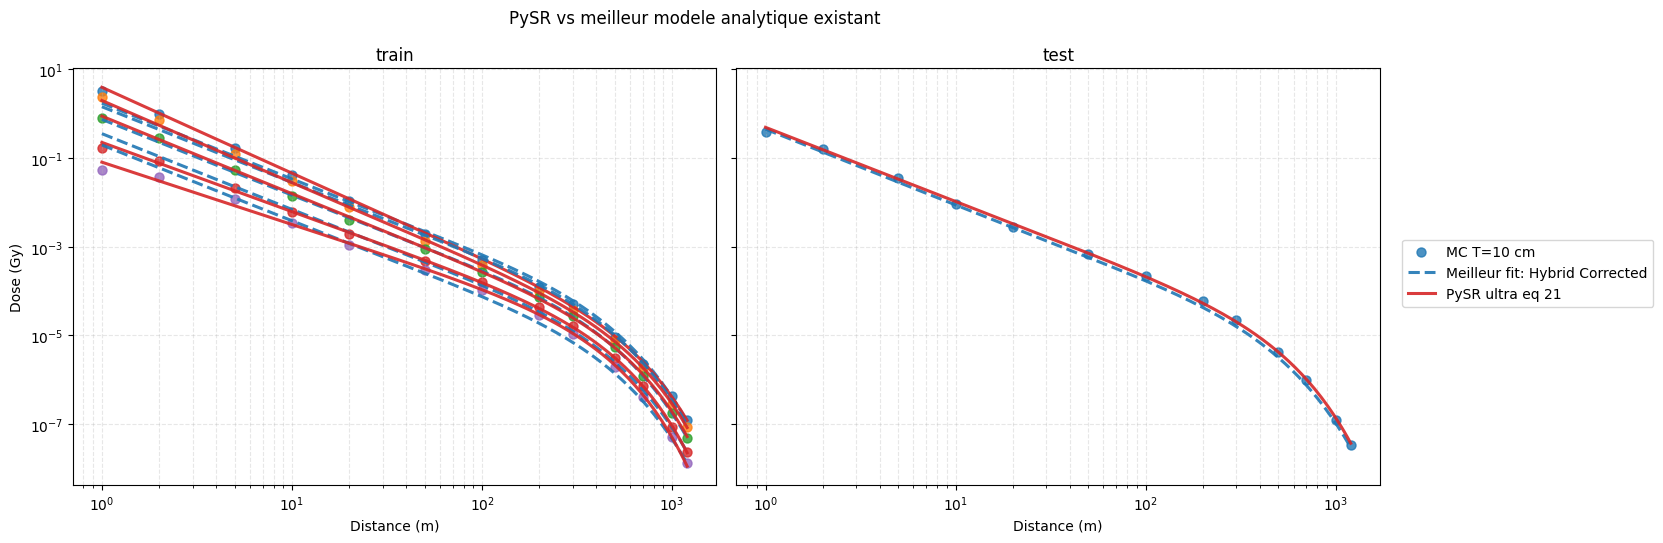

In [12]:
MODELS_TO_PLOT = [BEST_BASELINE_MODEL_NAME, "PySR selected"]
PYSR_R_SCALE = pysr_search_result["feature_bundle"]["r_scale"]
PYSR_T_SCALE = pysr_search_result["feature_bundle"]["t_scale"]

def make_pysr_feature_frame(frame):
    return build_feature_frame_with_scales(frame, PYSR_R_SCALE, PYSR_T_SCALE)

def predict_named_model(model_name, frame):
    if model_name == "PySR selected":
        return safe_exp(
            predict_log_with_model(
                pysr_model,
                make_pysr_feature_frame(frame),
                eq_number=PYSR_SELECTED_EQUATION_NUMBER,
            )
        )
    record = fitted_baselines[model_name]
    r, T, _ = _arrays_from_frame(frame)
    return record["predict"](record["params"], r, T)

plot_styles = {
    BEST_BASELINE_MODEL_NAME: {"color": "tab:blue", "linestyle": "--", "label": f"Meilleur fit: {BEST_BASELINE_MODEL_NAME}"},
    "PySR selected": {"color": "tab:red", "linestyle": "-", "label": f"PySR {PYSR_SELECTED_STAGE} eq {PYSR_SELECTED_EQUATION_NUMBER}"},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, split_name, frame in [(axes[0], "train", train_df), (axes[1], "test", test_df)]:
    thickness_values = sorted(frame["Thickness (cm)"].unique())
    for T_value in thickness_values:
        subset = frame[frame["Thickness (cm)"] == T_value].sort_values("Distance (m)")
        ax.scatter(
            subset["Distance (m)"],
            subset["Dose"],
            s=42,
            alpha=0.8,
            label=f"MC T={T_value:g} cm",
        )

        r_grid = np.logspace(np.log10(subset["Distance (m)"].min()), np.log10(subset["Distance (m)"].max()), 180)
        grid = pd.DataFrame({
            "Distance (m)": r_grid,
            "Thickness (cm)": np.full_like(r_grid, T_value, dtype=float),
            "Dose": np.nan,
        })

        for model_name in MODELS_TO_PLOT:
            pred = predict_named_model(model_name, grid)
            valid = (pred > 0) & np.isfinite(pred)
            style = plot_styles[model_name]
            ax.plot(
                r_grid[valid],
                pred[valid],
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=2.2,
                alpha=0.9,
                label=style["label"] if T_value == thickness_values[0] else None,
            )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Distance (m)")
    ax.set_title(split_name)
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Dose (Gy)")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.suptitle("PySR vs meilleur modele analytique existant")
fig.tight_layout()
plt.show()

## Visualisation PySR — toutes les épaisseurs

Vue globale du meilleur modèle PySR (et du meilleur modèle analytique) sur l'ensemble complet (train + test) pour chaque épaisseur disponible. Les points circulaires représentent le train, les triangles le test.

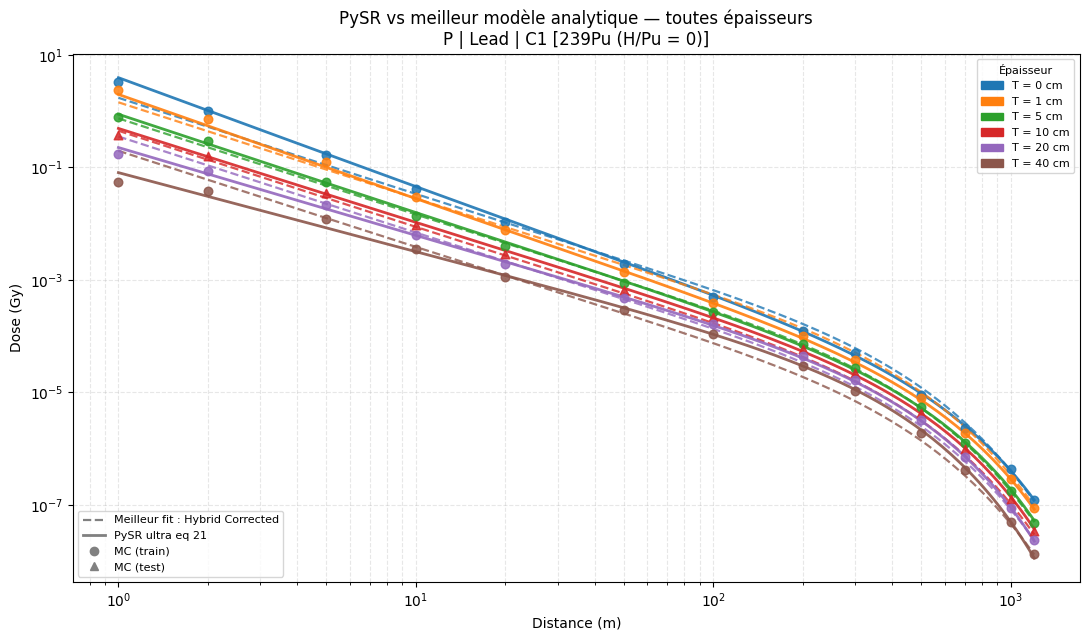

In [13]:
# Vue d'ensemble PySR sur toutes les épaisseurs (train + test)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

all_df = pd.concat([
    train_df.assign(_split="train"),
    test_df.assign(_split="test"),
], ignore_index=True)

thickness_values = sorted(all_df["Thickness (cm)"].unique())
cmap = plt.cm.tab10
colors = {T: cmap(i % 10) for i, T in enumerate(thickness_values)}

fig, ax = plt.subplots(figsize=(11, 6.5))

# Points MC (cercles = train, triangles = test)
for T_value in thickness_values:
    color = colors[T_value]
    for split, marker in [("train", "o"), ("test", "^")]:
        subset = all_df[
            (all_df["Thickness (cm)"] == T_value) & (all_df["_split"] == split)
        ].sort_values("Distance (m)")
        if subset.empty:
            continue
        ax.scatter(
            subset["Distance (m)"],
            subset["Dose"],
            color=color,
            marker=marker,
            s=38,
            alpha=0.85,
            zorder=4,
        )

# Courbes modèles
model_styles = {
    BEST_BASELINE_MODEL_NAME: {"linestyle": "--", "linewidth": 1.6, "alpha": 0.8},
    "PySR selected":           {"linestyle": "-",  "linewidth": 2.0, "alpha": 0.9},
}
for T_value in thickness_values:
    color = colors[T_value]
    sub = all_df[all_df["Thickness (cm)"] == T_value]
    r_min, r_max = sub["Distance (m)"].min(), sub["Distance (m)"].max()
    r_grid = np.logspace(np.log10(r_min), np.log10(r_max), 200)
    grid = pd.DataFrame({
        "Distance (m)": r_grid,
        "Thickness (cm)": np.full_like(r_grid, T_value, dtype=float),
        "Dose": np.nan,
    })
    for model_name, style in model_styles.items():
        pred = predict_named_model(model_name, grid)
        valid = (pred > 0) & np.isfinite(pred)
        ax.plot(r_grid[valid], pred[valid], color=color, **style)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Dose (Gy)")
title_info = " | ".join([
    particles[0] if len(particles) == 1 else str(particles),
    screens[0]   if len(screens)   == 1 else str(screens),
    cases[0]     if len(cases)     == 1 else str(cases),
])
ax.set_title("PySR vs meilleur modèle analytique \u2014 toutes épaisseurs\n" + title_info)
ax.grid(True, which="both", linestyle="--", alpha=0.3)

# Légende composée : couleurs = épaisseurs, styles = modèles
thickness_handles = [Patch(color=colors[T], label=f"T = {T:g} cm") for T in thickness_values]
model_handles = [
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1.6,
           label=f"Meilleur fit : {BEST_BASELINE_MODEL_NAME}"),
    Line2D([0], [0], color="gray", linestyle="-",  linewidth=2.0,
           label=f"PySR {PYSR_SELECTED_STAGE} eq {PYSR_SELECTED_EQUATION_NUMBER}"),
    Line2D([0], [0], color="gray", marker="o", linestyle="none", markersize=6, label="MC (train)"),
    Line2D([0], [0], color="gray", marker="^", linestyle="none", markersize=6, label="MC (test)"),
]
leg1 = ax.legend(handles=thickness_handles, title="Épaisseur", loc="upper right",
                 fontsize=8, title_fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=model_handles, loc="lower left", fontsize=8)

fig.tight_layout()
plt.show()

## Export

Activez `EXPORT_RESULTS = True` pour exporter les tableaux utiles dans `Notebooks/pysr_outputs/`.

In [14]:
EXPORT_RESULTS = False

PYSR_R_SCALE = pysr_search_result["feature_bundle"]["r_scale"]
PYSR_T_SCALE = pysr_search_result["feature_bundle"]["t_scale"]

print("Equation PySR selectionnee pour log_D:")
print(PYSR_SELECTED_SYMPY)
print("\nPrediction dose: Dose = exp(log_D)")
print(f"Variables: log_r=ln(r), r_scaled=r/{PYSR_R_SCALE:g}, T_scaled=T/{PYSR_T_SCALE:g}")
print(f"PySR retenu: stage={PYSR_SELECTED_STAGE}, eq={PYSR_SELECTED_EQUATION_NUMBER}")
print(f"Meilleur modele analytique: {BEST_BASELINE_MODEL_NAME}")

display(
    fit_decision_df.style.format({
        "test_median_relative_error_pct": "{:.2f}",
        "test_log_RMSE": "{:.4f}",
        "test_log_R2": "{:.6f}",
        "delta_median_error_vs_best_analytic": "{:+.2f}",
        "delta_log_RMSE_vs_best_analytic": "{:+.4f}",
    })
)

if EXPORT_RESULTS:
    output_dir = PROJECT_ROOT / "Notebooks" / "pysr_outputs"
    output_dir.mkdir(exist_ok=True)

    export_map = {
        "pysr_fit_decision.csv": fit_decision_df,
        "pysr_model_comparison.csv": comparison_df,
        "pysr_equation_candidates.csv": candidate_metrics_df,
        "pysr_selected_candidate.csv": pd.DataFrame([best_candidate_row]),
        "pysr_stage_summary.csv": pysr_stage_summary_df,
        "pysr_test_progress.csv": pysr_test_progress_df,
    }
    if not scenario_benchmark_df.empty:
        export_map["pysr_scenario_benchmark.csv"] = scenario_benchmark_df
    if not scenario_stage_benchmark_df.empty:
        export_map["pysr_scenario_stage_benchmark.csv"] = scenario_stage_benchmark_df

    for file_name, df_to_export in export_map.items():
        export_path = output_dir / file_name
        df_to_export.to_csv(export_path, index=False)
        print(f"Exporte: {export_path}")

Equation PySR selectionnee pour log_D:
r_scaled - 0.5392594*r_x_T + 0.5392594*(sqrt(T_scaled) + log_r - 4.5878806)*(sqrt(T_scaled) - 3.2962906*r_scaled - 3.6185315) - 7.5897675986232

Prediction dose: Dose = exp(log_D)
Variables: log_r=ln(r), r_scaled=r/1200, T_scaled=T/40
PySR retenu: stage=ultra, eq=21
Meilleur modele analytique: Hybrid Corrected


,model,family,test_median_relative_error_pct,test_log_RMSE,test_log_R2,delta_median_error_vs_best_analytic,delta_log_RMSE_vs_best_analytic
0,Hybrid Corrected,Modele analytique,17.16,0.2193,0.998107,+0.00,+0.0000
1,PySR ultra eq 21,PySR,8.11,0.1068,0.999551,-9.05,-0.1125


## Transfert de structure PySR vers un autre ensemble

La structure symbolique trouvee par PySR sur l'ensemble courant (source) est parametrisee en remplacant chaque constante numerique par un parametre libre, puis reajustee par `scipy.curve_fit` sur un ensemble cible different.

Cela repond a la question : **la meme forme d'equation peut-elle fitter un autre materiau ou cas ?**

Trois niveaux de comparaison sur la cible :
- **Application directe** : modele source applique tel quel (echelles source)
- **Reajustement** : meme structure, constantes refittees (echelles cible)
- **Modeles analytiques** : reference sur la cible

In [15]:
# ── Ensemble cible ────────────────────────────────────────────────────────
TARGET_PARTICLES       = ["P"]
TARGET_SCREENS         = ["Steel"]
TARGET_CASES           = ["C1 [239Pu (H/Pu = 0)]"]
TARGET_CODES           = ["MCNP 6"]
TARGET_THICKNESSES     = []
TARGET_INCLUDE_T0_NONE = True

_src = f"{particles[0]} | {screens[0]} | {cases[0]} | {codes[0]}"
_tgt = f"{TARGET_PARTICLES[0]} | {TARGET_SCREENS[0]} | {TARGET_CASES[0]} | {TARGET_CODES[0]}"
print(f"Source : {_src}")
print(f"Cible  : {_tgt}")

Source : P | Lead | C1 [239Pu (H/Pu = 0)] | MCNP 6
Cible  : P | Steel | C1 [239Pu (H/Pu = 0)] | MCNP 6


In [16]:
import sympy as sp
from scipy.optimize import curve_fit
import warnings

# ── 1. Chargement des donnees cibles ──────────────────────────────────────
_tgt_raw = filter_wall_df(
    data, TARGET_PARTICLES, TARGET_SCREENS, TARGET_CASES, TARGET_CODES,
    TARGET_THICKNESSES, plot=False
)
tgt_df = clean_fit_data(_tgt_raw)

if TARGET_INCLUDE_T0_NONE:
    _t0 = data[
        data["Particle"].isin(TARGET_PARTICLES)
        & (data["Screen"] == "None")
        & data["Case"].isin(TARGET_CASES)
        & data["Code"].isin(TARGET_CODES)
        & (data["Thickness (cm)"] == 0)
    ].copy()
    _t0 = clean_fit_data(_t0)
    if not _t0.empty:
        tgt_df = pd.concat([tgt_df, _t0], ignore_index=True)
        tgt_df = tgt_df.sort_values(["Thickness (cm)", "Distance (m)"]).reset_index(drop=True)
        print(f"  + {len(_t0)} points T=0 ajoutes")

if tgt_df.empty:
    raise ValueError("Aucune donnee cible. Verifiez TARGET_* parametres.")

print(f"Cible : {len(tgt_df)} points | epaisseurs = {sorted(tgt_df['Thickness (cm)'].unique())}")

_D_tgt = tgt_df["Dose"].to_numpy(dtype=float)
_y_tgt_log = np.log(_D_tgt)
_r_tgt, _T_tgt, _ = _arrays_from_frame(tgt_df)

# ── 2. Application directe (modele source, echelles source) ───────────────
_X_src_scale = build_feature_frame_with_scales(tgt_df, R_SCALE, T_SCALE)
try:
    _y_direct = predict_log_with_model(
        pysr_model, _X_src_scale, eq_number=PYSR_SELECTED_EQUATION_NUMBER
    )
    _m_direct = prediction_metrics(_D_tgt, safe_exp(_y_direct))
except Exception as _e:
    _m_direct = {"median_relative_error_pct": np.nan, "log_RMSE": np.nan, "log_R2": np.nan}
    print(f"  Application directe echouee : {_e}")

# ── 3. Parametrisation de l'equation PySR ─────────────────────────────────
_expr = sp.sympify(PYSR_SELECTED_SYMPY)

# Remplacer chaque constante Float unique par un parametre libre p0, p1, …
_floats = sorted({n for n in sp.preorder_traversal(_expr) if isinstance(n, sp.Float)}, key=float)
_psyms  = [sp.Symbol(f"__p{i}__") for i in range(len(_floats))]
_p0     = [float(c) for c in _floats]
_pexpr  = _expr.subs(dict(zip(_floats, _psyms)))

_ALL_FEAT = [
    "log_r", "r_scaled", "T_scaled",
    "exp_r_decay", "inv_r2", "T2_scaled",
    "log_r_x_T", "log_1pT", "r_x_T", "exp_T_decay", "inv_r2_x_eT",
]
_used = [f for f in _ALL_FEAT if sp.Symbol(f) in _pexpr.free_symbols]
_fsyms = [sp.Symbol(f) for f in _used]

print(f"\nStructure PySR : {PYSR_SELECTED_SYMPY}")
print(f"Constantes libres ({len(_psyms)}) : {[f'{v:.4g}' for v in _p0]}")
print(f"Features : {_used}")

_lambdified = sp.lambdify(_fsyms + _psyms, _pexpr, modules="numpy")

def _model_fn(X, *params):
    cols = [X[:, i] for i in range(X.shape[1])]
    with np.errstate(all="ignore"):
        return _lambdified(*cols, *params)

# ── 4. Reajustement des constantes sur la cible (echelles cible) ──────────
_tgt_r_scale = float(tgt_df["Distance (m)"].max())
_tgt_t_scale = float(max(tgt_df["Thickness (cm)"].max(), 1.0))
_X_tgt_df = build_feature_frame_with_scales(tgt_df, _tgt_r_scale, _tgt_t_scale)
_X_tgt = _X_tgt_df[_used].to_numpy(dtype=float)

_fit_ok = False
_popt = np.array(_p0)
if len(_p0) > 0:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            _popt, _ = curve_fit(_model_fn, _X_tgt, _y_tgt_log, p0=_p0, maxfev=200000)
        _fit_ok = True
    except Exception as _e:
        print(f"  curve_fit echoue ({_e}) — constantes source conservees.")

_y_refitted = _model_fn(_X_tgt, *_popt)
_m_refitted = prediction_metrics(_D_tgt, safe_exp(_y_refitted))

_refitted_expr = _pexpr.subs(dict(zip(_psyms, [sp.Float(p) for p in _popt])))
print(f"\nEquation refittee (ln(D)) :")
print(f"  {_refitted_expr}")

# ── 5. Modeles analytiques sur la cible ───────────────────────────────────
_analytics = {}
for _name, (_fit_fn, _pred_fn) in BASELINE_MODELS.items():
    try:
        _params_a = _fit_fn(_r_tgt, _T_tgt, _D_tgt)
        _pred_a   = _pred_fn(_params_a, _r_tgt, _T_tgt)
        _analytics[_name] = prediction_metrics(_D_tgt, _pred_a)
    except Exception:
        _analytics[_name] = {"median_relative_error_pct": np.nan, "log_RMSE": np.nan, "log_R2": np.nan}

# ── 6. Tableau de synthese ────────────────────────────────────────────────
_src_lbl = f"{particles[0]}|{screens[0]}|{cases[0]}"
_tgt_lbl = f"{TARGET_PARTICLES[0]}|{TARGET_SCREENS[0]}|{TARGET_CASES[0]}"

_rows = [
    {
        "modele": "PySR source — direct",
        "median_err_%": _m_direct["median_relative_error_pct"],
        "log_RMSE": _m_direct["log_RMSE"],
        "log_R2": _m_direct["log_R2"],
        "note": "constantes et echelles source, sans reajustement",
    },
    {
        "modele": "PySR source — reajuste",
        "median_err_%": _m_refitted["median_relative_error_pct"],
        "log_RMSE": _m_refitted["log_RMSE"],
        "log_R2": _m_refitted["log_R2"],
        "note": f"meme structure, {len(_psyms)} constantes refittees sur cible",
    },
]
for _name, _m in _analytics.items():
    _rows.append({
        "modele": _name,
        "median_err_%": _m["median_relative_error_pct"],
        "log_RMSE": _m["log_RMSE"],
        "log_R2": _m["log_R2"],
        "note": "modele analytique ajuste sur la cible",
    })

_summary_df = pd.DataFrame(_rows).sort_values("median_err_%", na_position="last")
print(f"\nTransfert  {_src_lbl}  →  {_tgt_lbl}")
display(
    _summary_df.style
    .format({"median_err_%": "{:.1f}", "log_RMSE": "{:.4f}", "log_R2": "{:.4f}"})
    .background_gradient(subset=["median_err_%"], cmap="RdYlGn_r", vmin=0, vmax=50)
)

# ── 7. Interpretation automatique ─────────────────────────────────────────
_best_analytic_err = min(
    (v["median_relative_error_pct"] for v in _analytics.values() if not np.isnan(v["median_relative_error_pct"])),
    default=np.nan,
)
_refit_err = _m_refitted["median_relative_error_pct"]
if not np.isnan(_refit_err) and not np.isnan(_best_analytic_err):
    if _refit_err < _best_analytic_err * 0.9:
        print(f"=> Structure PySR transferable et superieure ({_refit_err:.1f}% vs meilleur analytique {_best_analytic_err:.1f}%)")
    elif _refit_err < _best_analytic_err * 1.15:
        print(f"=> Structure PySR transferable, performances comparables ({_refit_err:.1f}% vs {_best_analytic_err:.1f}%)")
    else:
        print(f"=> Structure PySR peu transferable ({_refit_err:.1f}% vs meilleur analytique {_best_analytic_err:.1f}%) — lancer PySR directement sur la cible")

  + 13 points T=0 ajoutes
Cible : 78 points | epaisseurs = [0, 1, 5, 10, 20, 40]

Structure PySR : r_scaled - 0.5392594*r_x_T + 0.5392594*(sqrt(T_scaled) + log_r - 4.5878806)*(sqrt(T_scaled) - 3.2962906*r_scaled - 3.6185315) - 7.5897675986232
Constantes libres (6) : ['-7.59', '-4.588', '-3.619', '-3.296', '-0.5393', '0.5393']
Features : ['log_r', 'r_scaled', 'T_scaled', 'r_x_T']

Equation refittee (ln(D)) :
  r_scaled - 0.299843653384117*r_x_T + 0.299843653384117*(sqrt(T_scaled) + log_r - 4.8677189120932)*(sqrt(T_scaled) - 6.03953714538678*r_scaled - 6.61911135579969) - 7.96772421931205

Transfert  P|Lead|C1 [239Pu (H/Pu = 0)]  →  P|Steel|C1 [239Pu (H/Pu = 0)]


,modele,median_err_%,log_RMSE,log_R2,note
4,Skyshine Enhanced,9.1,0.1258,0.9994,modele analytique ajuste sur la cible
5,Super Hybrid,9.6,0.1441,0.9993,modele analytique ajuste sur la cible
3,Hybrid Corrected,10.9,0.1553,0.9992,modele analytique ajuste sur la cible
2,Simple Exponential,14.1,0.2402,0.9980,modele analytique ajuste sur la cible
1,PySR source — reajuste,22.5,0.2584,0.9977,"meme structure, 6 constantes refittees sur cible"
0,PySR source — direct,29.2,0.4558,0.9928,"constantes et echelles source, sans reajustement"


=> Structure PySR peu transferable (22.5% vs meilleur analytique 9.1%) — lancer PySR directement sur la cible


## Equation complete du meilleur modele PySR

Reconstruction de l'equation physique `D = exp(log_D)` en substituant les features normalisees par leur expression en `r` (m) et `T` (cm).

In [17]:
import sympy as sp
from IPython.display import display, Math

r_sym, T_sym = sp.symbols('r T', positive=True)
R_S = sp.Float(PYSR_R_SCALE)
T_S = sp.Float(PYSR_T_SCALE)

# Substitution features -> variables physiques (r en m, T en cm)
feature_subs = {
    sp.Symbol('log_r'):      sp.log(r_sym),
    sp.Symbol('r_scaled'):   r_sym / R_S,
    sp.Symbol('T_scaled'):   T_sym / T_S,
}
if USE_PHYSICS_FEATURES:
    feature_subs.update({
        sp.Symbol('exp_r_decay'): sp.exp(-r_sym / R_S),
        sp.Symbol('inv_r2'):      1 / (r_sym / R_S) ** 2,
        sp.Symbol('T2_scaled'):   (T_sym / T_S) ** 2,
    })
if USE_EXTENDED_PHYSICS_FEATURES:
    feature_subs.update({
        sp.Symbol('log_r_x_T'):   sp.log(r_sym) * (T_sym / T_S),
        sp.Symbol('log_1pT'):     sp.log(1 + T_sym / T_S),
        sp.Symbol('r_x_T'):       (r_sym / R_S) * (T_sym / T_S),
        sp.Symbol('exp_T_decay'):  sp.exp(-T_sym / T_S),
        sp.Symbol('inv_r2_x_eT'): sp.exp(-T_sym / T_S) / (r_sym / R_S) ** 2,
    })

log_D_expr   = sp.sympify(PYSR_SELECTED_SYMPY)
log_D_phys   = log_D_expr.subs(feature_subs)
D_expr       = sp.exp(log_D_phys)

sep = "=" * 68
print(sep)
print("MEILLEUR MODELE PySR — EQUATION COMPLETE")
print(sep)
print(f"Ensemble : {particles[0]} | {screens[0]} | {cases[0]} | {codes[0]}")
print(f"Stage    : {PYSR_SELECTED_STAGE}  eq #{PYSR_SELECTED_EQUATION_NUMBER}  "
      f"| R_SCALE={PYSR_R_SCALE:g} m  T_SCALE={PYSR_T_SCALE:g} cm")
print()
print("[ Forme brute PySR — variables normalisees ]")
print(f"  ln(D) = {PYSR_SELECTED_SYMPY}")
print()
print("[ Forme physique — r en m, T en cm ]")
print(f"  ln(D) = {log_D_phys}")
print()
print("[ Equation finale ]")
print(f"  D(r, T) = exp( {log_D_phys} )")
print(sep)
print()
print("Rendu LaTeX :")
display(Math(r"D(r,\,T) = \exp\!\left(" + sp.latex(log_D_phys) + r"\right)"))

MEILLEUR MODELE PySR — EQUATION COMPLETE
Ensemble : P | Lead | C1 [239Pu (H/Pu = 0)] | MCNP 6
Stage    : ultra  eq #21  | R_SCALE=1200 m  T_SCALE=40 cm

[ Forme brute PySR — variables normalisees ]
  ln(D) = r_scaled - 0.5392594*r_x_T + 0.5392594*(sqrt(T_scaled) + log_r - 4.5878806)*(sqrt(T_scaled) - 3.2962906*r_scaled - 3.6185315) - 7.5897675986232

[ Forme physique — r en m, T en cm ]
  ln(D) = -1.12345708333333e-5*T*r + 0.000833333333333333*r + 0.5392594*(0.158113883008419*sqrt(T) - 0.00274690883333333*r - 3.6185315)*(0.158113883008419*sqrt(T) + log(r) - 4.5878806) - 7.5897675986232

[ Equation finale ]
  D(r, T) = exp( -1.12345708333333e-5*T*r + 0.000833333333333333*r + 0.5392594*(0.158113883008419*sqrt(T) - 0.00274690883333333*r - 3.6185315)*(0.158113883008419*sqrt(T) + log(r) - 4.5878806) - 7.5897675986232 )

Rendu LaTeX :


<IPython.core.display.Math object>